In [11]:
# ============================================
# CELL 0.1: IMPORT ALL LIBRARIES
# ============================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Arabic text processing
import re

# Word cloud
from wordcloud import WordCloud
from collections import Counter

# Set style for plots
plt.style.use('ggplot')
sns.set_palette("husl")

# Display all columns when printing
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# For displaying Arabic in plots
import arabic_reshaper
from bidi.algorithm import get_display

print("All libraries imported successfully!")
print("Ready for EDA!")

All libraries imported successfully!
Ready for EDA!


In [12]:
# ============================================
# CELL 0.2: LOAD DATASET & FIRST LOOK
# ============================================

# Load the CSV file
df = pd.read_csv('/kaggle/input/datasets/salahzaoui/lsahrcsv/LSAHR.csv')

# ============================================
# 1. BASIC INFORMATION
# ============================================
print("=" * 60)
print(" DATASET OVERVIEW")
print("=" * 60)

# Shape of dataset
print(f"\n Shape: {df.shape[0]} rows × {df.shape[1]} columns")

# Column names
print(f"\n Columns ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")

# ============================================
# 2. FIRST 5 ROWS
# ============================================
print("\n" + "=" * 60)
print(" FIRST 5 ROWS")
print("=" * 60)
display(df.head())

# ============================================
# 3. DATA TYPES
# ============================================
print("\n" + "=" * 60)
print(" DATA TYPES")
print("=" * 60)
print(df.dtypes)

# ============================================
# 4. MISSING VALUES
# ============================================
print("\n" + "=" * 60)
print(" MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': missing_pct.round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0]
if len(missing_df) > 0:
    print(missing_df)
else:
    print(" No missing values found!")

# ============================================
# 5. QUICK STATS ON user_rating
# ============================================
print("\n" + "=" * 60)
print(" USER RATING STATISTICS")
print("=" * 60)
print(df['user_rating'].describe())

print("\n Dataset loaded successfully!")


 DATASET OVERVIEW

 Shape: 122679 rows × 15 columns

 Columns (15):
   1. hotel_id
   2. hotel_name
   3. location
   4. distance_from_city_center
   5. country
   6. hotel_rating
   7. price
   8. user_id
   9. username
   10. nationality
   11. user_rating
   12. review
   13. review_date
   14. traveler_type
   15. stay_duration

 FIRST 5 ROWS


,hotel_id,hotel_name,location,distance_from_city_center,country,hotel_rating,price,user_id,username,nationality,user_rating,review,review_date,traveler_type,stay_duration
0,822998,Conscious Hotel The Tire Station,"أود - فيست, أمستردام",3.1,أمستردام,8.4,"42,905 DZD",64985443,Nancy,ألمانيا,6.0,موقع ممتاز بالقرب من اطفالنا واحفادنا عظام عاريه حقًا مقابل يورو لمده ثلاث ليال لا يوجد ابدًا م...,11/06/2023,2,3
1,46798,ibis budget Krakow Stare Miasto,"المدينة القديمة, كراكوف",1.1,كراكوف,8.1,"21,610 DZD",75022101,Magdalena,هولندا,8.0,السعر مناسب للجوده نظيفه وهادءه، والاهم من ذلك الاسوا هي الاكواخ من الخارج، وخاصه من المحطه تكيي...,12/06/2025,1,1
2,886978,Courtyard by Marriott Casablanca Downtown,"معارف, الدار البيضاء",2.9,الدار البيضاء,8.7,"79,911 DZD",12031037,محمد,المملكة العربية السعودية,7.0,النظافه ضيق الغرفه,01/11/2024,2,2
3,595399,The Hotel Syracuse,"Sidi Belyout, الدار البيضاء",0.1,الدار البيضاء,7.6,"33,825 DZD",93878668,Ann,الولايات المتحدة الأمريكية,5.0,كان الافطار جيد علي الرغم من اننا فوجءنا القهوه كانت مقابل رسوم اضافيه الموقع كان روعها علي الرغ...,14/04/2025,2,3
4,673038,Vienna House by Wyndham Andel's Cracow,"المدينة القديمة, كراكوف",0.7,كراكوف,9.1,"36,589 DZD",29618381,Asli,تركيا,9.0,الموقع المثالي،,23/03/2025,3,2



 DATA TYPES
hotel_id                       int64
hotel_name                    object
location                      object
distance_from_city_center    float64
country                       object
hotel_rating                 float64
price                         object
user_id                        int64
username                      object
nationality                   object
user_rating                  float64
review                        object
review_date                   object
traveler_type                  int64
stay_duration                  int64
dtype: object

 MISSING VALUES
 No missing values found!

 USER RATING STATISTICS
count    122679.000000
mean          7.543567
std           2.495508
min           1.000000
25%           6.000000
50%           8.000000
75%          10.000000
max          10.000000
Name: user_rating, dtype: float64

 Dataset loaded successfully!


In [13]:
# Count rows where nationality is 'اسرائيل' and remove it 
israel_mask = df['nationality'] == 'إسرائيل'
israel_count = israel_mask.sum()
print(israel_count)
df = df[~israel_mask].copy()
print(f"Filtered dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

1113
Filtered dataset shape: 121566 rows × 15 columns


In [14]:
# ============================================
# CELL 3: FILTER ARABIC REVIEWS + FIX DISPLAY + DETECTION
# ============================================

import arabic_reshaper
from bidi.algorithm import get_display

# ============================================
# 1. ARABIC DETECTION FUNCTION
# ============================================

def is_arabic(text):
    """
    Check if a text is mostly Arabic.
    Uses wider Unicode ranges to catch all Arabic characters.
    """
    if not isinstance(text, str):
        return False
    
    # Wider Arabic Unicode range (includes Arabic, Arabic Supplement, Arabic Extended)
    arabic_ranges = [
        ('\u0600', '\u06FF'),   # Arabic
        ('\u0750', '\u077F'),   # Arabic Supplement
        ('\u08A0', '\u08FF'),   # Arabic Extended-A
        ('\uFB50', '\uFDFF'),   # Arabic Presentation Forms-A
        ('\uFE70', '\uFEFF'),   # Arabic Presentation Forms-B
    ]
    
    arabic_count = 0
    total_count = 0
    
    for char in text:
        if char.isalpha():
            total_count += 1
            for start, end in arabic_ranges:
                if start <= char <= end:
                    arabic_count += 1
                    break
    
    if total_count == 0:
        return False
    
    return (arabic_count / total_count) > 0.3


# ============================================
# 2. DISPLAY FUNCTION
# ============================================

def show(text, max_len=200):
    """
    Display text - works even if terminal can't render Arabic perfectly.
    """
    if not isinstance(text, str):
        return text
    if len(text) > max_len:
        text = text[:max_len] + "..."
    try:
        return arabic_reshaper.reshape(text)
    except:
        return text


# ============================================
# 3. FILTER ARABIC REVIEWS
# ============================================

df_arabic = df[df['review'].apply(is_arabic)].copy()

print("=" * 60)
print("ARABIC REVIEW FILTER RESULTS")
print("=" * 60)
print(f"Original dataset:   {len(df)} reviews")
print(f"Arabic reviews:     {len(df_arabic)} reviews")
print(f"Removed:            {len(df) - len(df_arabic)} reviews")
print(f"Percentage Arabic:  {(len(df_arabic)/len(df))*100:.1f}%")
print()

# ============================================
# 4. VERIFY DATA INTEGRITY
# ============================================

sample_review = df_arabic['review'].iloc[10]
print("=" * 60)
print("DATA INTEGRITY CHECK")
print("=" * 60)
print(f"First review length: {len(sample_review)} characters")
print(f"Arabic detection:    {is_arabic(sample_review)}")
print(f"Sample text:         {sample_review[:80]}...")
print()

ARABIC REVIEW FILTER RESULTS
Original dataset:   121566 reviews
Arabic reviews:     121566 reviews
Removed:            0 reviews
Percentage Arabic:  100.0%

DATA INTEGRITY CHECK
First review length: 619 characters
Arabic detection:    True
Sample text:         سكن جيد ليس بعيدًا عن المركز، دقيقه سيرًا علي الاقدام، منطقه لطيفه بها الكثير من...



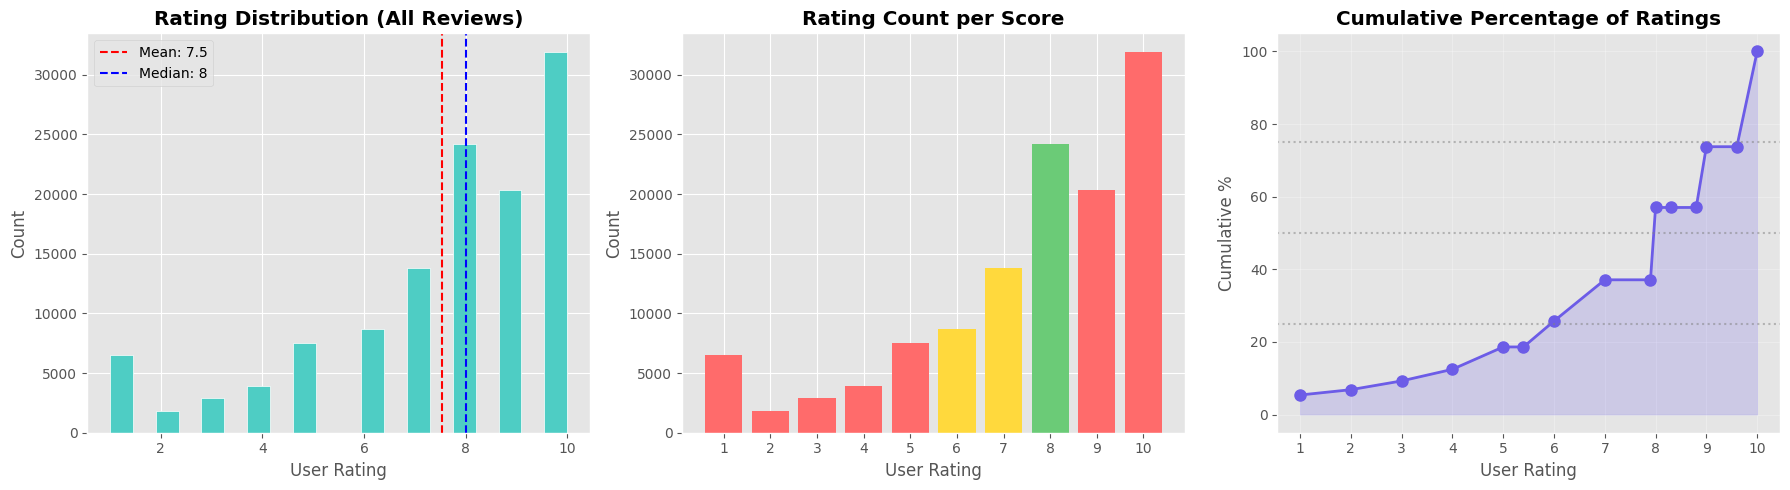

RATING STATISTICS
Mean rating:   7.54
Median rating: 8
Std deviation: 2.50

Rating distribution:
    1.0:   6546 (  5.4%) |||||
    2.0:   1784 (  1.5%) |
    3.0:   2934 (  2.4%) ||
    4.0:   3883 (  3.2%) |||
    5.0:   7494 (  6.2%) ||||||
    5.4:      1 (  0.0%) 
    6.0:   8660 (  7.1%) |||||||
    7.0:  13816 ( 11.4%) |||||||||||
    7.9:      1 (  0.0%) 
    8.0:  24218 ( 19.9%) |||||||||||||||||||
    8.3:      3 (  0.0%) 
    8.8:      3 (  0.0%) 
    9.0:  20343 ( 16.7%) ||||||||||||||||
    9.6:      1 (  0.0%) 
   10.0:  31879 ( 26.2%) ||||||||||||||||||||||||||

COMPARING DIFFERENT CLASS SPLIT OPTIONS

Split A (1-4 Neg, 5-6 Neu, 7-10 Pos):
  Negative (1-4):  15147 (12.5%)
  Neutral  (5-6):  16155 (13.3%)
  Positive (7-10):  90264 (74.3%)

Split B (1-6 Neg, 7-8 Neu, 9-10 Pos):
  Negative (1-6):  31302 (25.8%)
  Neutral  (7-8):  38035 (31.3%)
  Positive (9-10):  52223 (43.0%)

Split C (1-5 Neg, 6-10 Pos):
  Negative (1-5):  22641 (18.6%)
  Positive (6-10):  98924 (81.4%)



In [15]:
# ============================================
# CELL 5C: EXTENDED EDA - UNDERSTAND RATINGS
# ============================================

import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display
from collections import Counter
import re

# ============================================
# 1. RATING DISTRIBUTION - DETAILED
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Histogram of ratings
axes[0].hist(df_arabic['user_rating'], bins=20, color='#4ECDC4', edgecolor='white')
axes[0].axvline(df_arabic['user_rating'].mean(), color='red', linestyle='--', 
                label=f'Mean: {df_arabic["user_rating"].mean():.1f}')
axes[0].axvline(df_arabic['user_rating'].median(), color='blue', linestyle='--', 
                label=f'Median: {df_arabic["user_rating"].median():.0f}')
axes[0].set_title('Rating Distribution (All Reviews)', fontweight='bold')
axes[0].set_xlabel('User Rating')
axes[0].set_ylabel('Count')
axes[0].legend()

# Plot B: Rating counts with percentage
rating_counts = df_arabic['user_rating'].value_counts().sort_index()
colors_bar = ['#FF6B6B']*6 + ['#FFD93D']*2 + ['#6BCB77']*3
axes[1].bar(rating_counts.index, rating_counts.values, color=colors_bar)
axes[1].set_title('Rating Count per Score', fontweight='bold')
axes[1].set_xlabel('User Rating')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(1, 11))

# Plot C: Cumulative percentage
cumulative = rating_counts.cumsum() / rating_counts.sum() * 100
axes[2].plot(cumulative.index, cumulative.values, 'o-', color='#6C5CE7', linewidth=2, markersize=8)
axes[2].fill_between(cumulative.index, 0, cumulative.values, alpha=0.2, color='#6C5CE7')
axes[2].set_title('Cumulative Percentage of Ratings', fontweight='bold')
axes[2].set_xlabel('User Rating')
axes[2].set_ylabel('Cumulative %')
axes[2].set_xticks(range(1, 11))
axes[2].grid(True, alpha=0.3)

# Add horizontal lines at key points
for pct in [25, 50, 75]:
    axes[2].axhline(y=pct, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# ============================================
# 2. PRINT STATISTICS
# ============================================

print("=" * 60)
print("RATING STATISTICS")
print("=" * 60)
print(f"Mean rating:   {df_arabic['user_rating'].mean():.2f}")
print(f"Median rating: {df_arabic['user_rating'].median():.0f}")
print(f"Std deviation: {df_arabic['user_rating'].std():.2f}")
print()
print("Rating distribution:")
for rating in sorted(df_arabic['user_rating'].unique()):
    count = (df_arabic['user_rating'] == rating).sum()
    pct = count / len(df_arabic) * 100
    bar = '|' * int(pct)
    print(f"  {rating:5.1f}: {count:6d} ({pct:5.1f}%) {bar}")

# ============================================
# 3. WHAT IF DIFFERENT SPLITS? (For Decision Making)
# ============================================

print()
print("=" * 60)
print("COMPARING DIFFERENT CLASS SPLIT OPTIONS")
print("=" * 60)

splits = {
    'Split A (1-4 Neg, 5-6 Neu, 7-10 Pos)': [(1,4), (5,6), (7,10)],
    'Split B (1-6 Neg, 7-8 Neu, 9-10 Pos)': [(1,6), (7,8), (9,10)],
    'Split C (1-5 Neg, 6-10 Pos)': [(1,5), (6,10)],
    'Split D (1-4 Neg, 5-10 Pos)': [(1,8), (9,10)],
}

for split_name, ranges in splits.items():
    if len(ranges) == 3:
        low = ((df_arabic['user_rating'] >= ranges[0][0]) & (df_arabic['user_rating'] <= ranges[0][1])).sum()
        mid = ((df_arabic['user_rating'] >= ranges[1][0]) & (df_arabic['user_rating'] <= ranges[1][1])).sum()
        high = ((df_arabic['user_rating'] >= ranges[2][0]) & (df_arabic['user_rating'] <= ranges[2][1])).sum()
        total = low + mid + high
        print(f"\n{split_name}:")
        print(f"  Negative ({ranges[0][0]}-{ranges[0][1]}): {low:6d} ({low/total*100:.1f}%)")
        print(f"  Neutral  ({ranges[1][0]}-{ranges[1][1]}): {mid:6d} ({mid/total*100:.1f}%)")
        print(f"  Positive ({ranges[2][0]}-{ranges[2][1]}): {high:6d} ({high/total*100:.1f}%)")
    else:
        neg = ((df_arabic['user_rating'] >= ranges[0][0]) & (df_arabic['user_rating'] <= ranges[0][1])).sum()
        pos = ((df_arabic['user_rating'] >= ranges[1][0]) & (df_arabic['user_rating'] <= ranges[1][1])).sum()
        total = neg + pos
        print(f"\n{split_name}:")
        print(f"  Negative ({ranges[0][0]}-{ranges[0][1]}): {neg:6d} ({neg/total*100:.1f}%)")
        print(f"  Positive ({ranges[1][0]}-{ranges[1][1]}): {pos:6d} ({pos/total*100:.1f}%)")

print()
print("=" * 60)
print("Current choice: Split B (1-6 Neg, 7-8 Neu, 9-10 Pos)")
print("=" * 60)

In [16]:
# ============================================
# CELL 4: BINARY LABELS (POSITIVE = 9-10)
# ============================================

import numpy as np

# ============================================
# 1. CREATE BINARY LABELS
# ============================================

def convert_to_binary(rating):
    """
    1-8 = Negative (0)
    9-10 = Positive (1)
    """
    if rating <= 8:
        return 0  # Negative
    else:
        return 1  # Positive

df_clean = df_arabic.copy()
df_clean['sentiment'] = df_clean['user_rating'].apply(convert_to_binary)

label_names = {0: 'Negative', 1: 'Positive'}

# ============================================
# 2. RESULTS
# ============================================

total = len(df_clean)
neg = (df_clean['sentiment'] == 0).sum()
pos = (df_clean['sentiment'] == 1).sum()

print("=" * 60)
print("FINAL DATASET: BINARY CLASSIFICATION")
print("=" * 60)
print(f"Total reviews:           {total}")
print()
print(f"Negative (1-8):          {neg} ({neg/total*100:.1f}%)")
print(f"Positive (9-10):         {pos} ({pos/total*100:.1f}%)")
print()

# ============================================
# 3. CHECK BALANCE
# ============================================

ratio = max(neg, pos) / min(neg, pos)
print(f"Class ratio:             {ratio:.1f}:1")
if ratio < 2:
    print("Balance:                 GOOD - No class weights needed")
else:
    print("Balance:                 NEEDS class weights")
print()

print("=" * 60)
print("STRATEGY SUMMARY")
print("=" * 60)
print("Model:       Binary classification")
print("Metric:      Accuracy + F1-score")
print("Split:       Stratified train/test")
print()
print("Ready for preprocessing.")
print("=" * 60)

FINAL DATASET: BINARY CLASSIFICATION
Total reviews:           121566

Negative (1-8):          69337 (57.0%)
Positive (9-10):         52229 (43.0%)

Class ratio:             1.3:1
Balance:                 GOOD - No class weights needed

STRATEGY SUMMARY
Model:       Binary classification
Metric:      Accuracy + F1-score
Split:       Stratified train/test

Ready for preprocessing.


In [17]:
# ============================================
# CELL 6B: ARABIC NORMALIZATION & STOP WORDS (NLTK)
# ============================================

import re
import nltk
from nltk.corpus import stopwords

# Download Arabic stop words (run once)
nltk.download('stopwords', quiet=True)

# Load Arabic stop words from NLTK
ARABIC_STOP_WORDS = set(stopwords.words('arabic'))

print(f"Loaded {len(ARABIC_STOP_WORDS)} Arabic stop words from NLTK")
print(f"Examples: {list(ARABIC_STOP_WORDS)[:15]}")

# ============================================
# 1. ARABIC NORMALIZATION
# ============================================

def normalize_arabic(text):
    """
    Normalize Arabic text by unifying different forms of letters.
    """
    if not isinstance(text, str):
        return ""
    
    # Normalize Alef variants (إ أ آ ا) to bare Alef (ا)
    text = re.sub('[إأآا]', 'ا', text)
    
    # Normalize Yeh variants (ي ى) to Yeh without dots (ي)
    text = re.sub('[يى]', 'ي', text)
    
    # Normalize Teh Marbuta (ة) to Heh (ه)
    text = re.sub('ة', 'ه', text)
    
    # Remove diacritics (tashkeel: Fatha, Damma, Kasra, etc.)
    text = re.sub('[\u064B-\u065F\u0670]', '', text)
    
    # Remove tatweel (elongation character: ـ)
    text = re.sub('\u0640', '', text)
    
    # Remove extra spaces
    text = re.sub('\s+', ' ', text).strip()
    
    return text


# ============================================
# 2. REMOVE STOP WORDS (using NLTK)
# ============================================

def remove_stopwords(text):
    """
    Remove Arabic stop words from text using NLTK list.
    """
    if not isinstance(text, str):
        return ""
    
    words = text.split()
    filtered_words = [word for word in words if word not in ARABIC_STOP_WORDS]
    return ' '.join(filtered_words)


# ============================================
# 3. TWO PREPROCESSING PIPELINES
# ============================================

def preprocess_classical(text):
    """
    Heavy preprocessing for classical ML models.
    Includes normalization AND stop word removal.
    """
    if not isinstance(text, str):
        return ""
    
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'[a-zA-Z]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)
    text = normalize_arabic(text)
    text = remove_stopwords(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def preprocess_transformer(text):
    """
    Light preprocessing for transformer models.
    Normalization only. NO stop word removal.
    """
    if not isinstance(text, str):
        return ""
    
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'[a-zA-Z]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)
    text = normalize_arabic(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# ============================================
# 4. TEST BOTH PIPELINES
# ============================================

# Use the 'review' column (it exists)
sample_text = df_clean['review'].iloc[0]

print()
print("=" * 60)
print("TEST: CLASSICAL vs TRANSFORMER PREPROCESSING")
print("=" * 60)
print(f"\nORIGINAL ({len(sample_text.split())} words):")
print(sample_text[:250])
print(f"\nCLASSICAL ({len(preprocess_classical(sample_text).split())} words):")
print(preprocess_classical(sample_text)[:250])
print(f"\nTRANSFORMER ({len(preprocess_transformer(sample_text).split())} words):")
print(preprocess_transformer(sample_text)[:250])

print()
print("=" * 60)
print("Preprocessing functions ready for Cell 7.")
print("=" * 60)

<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_58/2307246368.py:45: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub('\s+', ' ', text).strip()


Loaded 701 Arabic stop words from NLTK
Examples: ['صار', 'يوليو', 'عامة', 'بماذا', 'بك', 'ج', 'بل', 'حجا', 'رُبَّ', 'علق', 'ذات', 'ئ', 'أنّى', 'وهو', 'كن']

TEST: CLASSICAL vs TRANSFORMER PREPROCESSING

ORIGINAL (32 words):
موقع ممتاز بالقرب من اطفالنا واحفادنا عظام عاريه حقًا مقابل  يورو لمده ثلاث ليال لا يوجد ابدًا منشفتا وجه ومنشفتي دش عند الوصول يمكن ان يكون هناك عدد قليل من الانسجه ايضا

CLASSICAL (24 words):
موقع ممتاز بالقرب اطفالنا واحفادنا عظام عاريه مقابل لمده ليال يوجد ابدا منشفتا وجه ومنشفتي دش الوصول يمكن ان يكون عدد قليل الانسجه ايضا

TRANSFORMER (32 words):
موقع ممتاز بالقرب من اطفالنا واحفادنا عظام عاريه حقا مقابل يورو لمده ثلاث ليال لا يوجد ابدا منشفتا وجه ومنشفتي دش عند الوصول يمكن ان يكون هناك عدد قليل من الانسجه ايضا

Preprocessing functions ready for Cell 7.


In [18]:
# ============================================
# CELL 7: TRAIN/TEST SPLIT (BOTH PIPELINES)
# ============================================

from sklearn.model_selection import train_test_split

# ============================================
# 1. APPLY BOTH PREPROCESSING PIPELINES
# ============================================

df_clean['review_classical'] = df_clean['review'].apply(preprocess_classical)
df_clean['review_transformer'] = df_clean['review'].apply(preprocess_transformer)

# Remove empty reviews after cleaning
df_clean = df_clean[df_clean['review_classical'].str.len() > 5].copy()
df_clean = df_clean[df_clean['review_transformer'].str.len() > 5].copy()
df_clean = df_clean.reset_index(drop=True)

# ============================================
# 2. TRAIN/TEST SPLIT
# ============================================

# For classical models
X_classical = df_clean['review_classical'].values
# For transformer models
X_transformer = df_clean['review_transformer'].values
# Labels
y = df_clean['sentiment'].values

# Split (same indexes for both pipelines)
X_train_classical, X_test_classical, y_train, y_test = train_test_split(
    X_classical, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_transformer, X_test_transformer, _, _ = train_test_split(
    X_transformer, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ============================================
# 3. RESULTS
# ============================================

label_names = {0: 'Negative', 1: 'Positive'}

print("=" * 60)
print("TRAIN/TEST SPLIT RESULTS")
print("=" * 60)
print(f"Total reviews after cleaning: {len(df_clean)}")
print(f"Training set:   {len(X_train_classical)} reviews")
print(f"Test set:       {len(X_test_classical)} reviews")
print()

for name, y_set in [('Training', y_train), ('Test', y_test)]:
    neg = (y_set == 0).sum()
    pos = (y_set == 1).sum()
    print(f"{name} set:")
    print(f"  Negative: {neg} ({neg/len(y_set)*100:.1f}%)")
    print(f"  Positive: {pos} ({pos/len(y_set)*100:.1f}%)")

print()
print("=" * 60)
print("Variables ready for Phase 2:")
print("=" * 60)
print("  X_train_classical / X_test_classical (for TF-IDF)")
print("  X_train_transformer / X_test_transformer (for AraBERT)")
print("  y_train / y_test (shared labels: 0=Negative, 1=Positive)")
print()
print("Phase 1 complete. Ready for classical models.")
print("=" * 60)

TRAIN/TEST SPLIT RESULTS
Total reviews after cleaning: 121452
Training set:   97161 reviews
Test set:       24291 reviews

Training set:
  Negative: 55435 (57.1%)
  Positive: 41726 (42.9%)
Test set:
  Negative: 13859 (57.1%)
  Positive: 10432 (42.9%)

Variables ready for Phase 2:
  X_train_classical / X_test_classical (for TF-IDF)
  X_train_transformer / X_test_transformer (for AraBERT)
  y_train / y_test (shared labels: 0=Negative, 1=Positive)

Phase 1 complete. Ready for classical models.


In [19]:
# ============================================
# CELL 8: TF-IDF + NAIVE BAYES
# ============================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import time

# ============================================
# 1. TF-IDF VECTORIZATION
# ============================================

print("Vectorizing text with TF-IDF...")
start_time = time.time()

tfidf = TfidfVectorizer(
    max_features=5000,      # Top 5000 words
    ngram_range=(1, 2),     # Unigrams + Bigrams
    min_df=3                # Appears in at least 3 documents
)

X_train_tfidf = tfidf.fit_transform(X_train_classical)
X_test_tfidf = tfidf.transform(X_test_classical)

vectorize_time = time.time() - start_time
print(f"TF-IDF shape: {X_train_tfidf.shape}")
print(f"Vectorization time: {vectorize_time:.2f} seconds")

# ============================================
# 2. TRAIN NAIVE BAYES
# ============================================

print("\nTraining Naive Bayes...")
start_time = time.time()

nb_model = MultinomialNB(alpha=0.1)  # alpha for smoothing
nb_model.fit(X_train_tfidf, y_train)

train_time = time.time() - start_time
print(f"Training time: {train_time:.2f} seconds")

# ============================================
# 3. PREDICT & EVALUATE
# ============================================

y_pred_nb = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb, average='macro')
nb_recall = recall_score(y_test, y_pred_nb, average='macro')
nb_f1 = f1_score(y_test, y_pred_nb, average='macro')

print()
print("=" * 60)
print("NAIVE BAYES RESULTS")
print("=" * 60)
print(f"Accuracy:  {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall:    {nb_recall:.4f}")
print(f"F1-Score:  {nb_f1:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['Negative', 'Positive']))
print("=" * 60)

# ============================================
# 4. STORE RESULTS FOR LATER COMPARISON
# ============================================

results = {
    'Naive Bayes': {
        'Accuracy': nb_accuracy,
        'Precision': nb_precision,
        'Recall': nb_recall,
        'F1-Score': nb_f1,
        'Train Time': train_time,
        'Predictions': y_pred_nb
    }
}

print("\nNaive Bayes complete. Ready for Logistic Regression.")

Vectorizing text with TF-IDF...
TF-IDF shape: (97161, 5000)
Vectorization time: 6.57 seconds

Training Naive Bayes...
Training time: 0.02 seconds

NAIVE BAYES RESULTS
Accuracy:  0.7007
Precision: 0.6956
Recall:    0.6860
F1-Score:  0.6881

Classification Report:
              precision    recall  f1-score   support

    Negative       0.72      0.79      0.75     13859
    Positive       0.68      0.58      0.63     10432

    accuracy                           0.70     24291
   macro avg       0.70      0.69      0.69     24291
weighted avg       0.70      0.70      0.70     24291


Naive Bayes complete. Ready for Logistic Regression.


In [20]:
# ============================================
# CELL 9: TF-IDF + LOGISTIC REGRESSION
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import time

# ============================================
# 1. TRAIN LOGISTIC REGRESSION
# ============================================

print("Training Logistic Regression...")
start_time = time.time()

lr_model = LogisticRegression(
    max_iter=1000,           # More iterations for convergence
    C=1.0,                   # Regularization strength
    class_weight='balanced', # Handle class imbalance
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

train_time = time.time() - start_time
print(f"Training time: {train_time:.2f} seconds")

# ============================================
# 2. PREDICT & EVALUATE
# ============================================

y_pred_lr = lr_model.predict(X_test_tfidf)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, average='macro')
lr_recall = recall_score(y_test, y_pred_lr, average='macro')
lr_f1 = f1_score(y_test, y_pred_lr, average='macro')

print()
print("=" * 60)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 60)
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Negative', 'Positive']))
print("=" * 60)

# ============================================
# 3. TOP POSITIVE & NEGATIVE WORDS
# ============================================

# Get feature names
feature_names = tfidf.get_feature_names_out()

# Get coefficients (works for binary classification)
coefficients = lr_model.coef_[0]

# Top words for each class
top_positive_idx = coefficients.argsort()[-10:][::-1]
top_negative_idx = coefficients.argsort()[:10]

print("\n" + "=" * 60)
print("TOP WORDS INFLUENCING PREDICTIONS")
print("=" * 60)
print("\nTop Positive words:")
for idx in top_positive_idx:
    print(f"  {feature_names[idx]}: {coefficients[idx]:.4f}")

print("\nTop Negative words:")
for idx in top_negative_idx:
    print(f"  {feature_names[idx]}: {coefficients[idx]:.4f}")
print("=" * 60)

# ============================================
# 4. STORE RESULTS
# ============================================

results['Logistic Regression'] = {
    'Accuracy': lr_accuracy,
    'Precision': lr_precision,
    'Recall': lr_recall,
    'F1-Score': lr_f1,
    'Train Time': train_time,
    'Predictions': y_pred_lr
}

print("\nLogistic Regression complete. Ready for SVM.")

Training Logistic Regression...
Training time: 0.70 seconds

LOGISTIC REGRESSION RESULTS
Accuracy:  0.7026
Precision: 0.7008
Recall:    0.7047
F1-Score:  0.7005

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.69      0.73     13859
    Positive       0.64      0.72      0.68     10432

    accuracy                           0.70     24291
   macro avg       0.70      0.70      0.70     24291
weighted avg       0.71      0.70      0.70     24291


TOP WORDS INFLUENCING PREDICTIONS

Top Positive words:
  شكرا: 2.8718
  الاستاذه: 2.6630
  ممتاز: 2.6196
  اجمل: 2.5615
  الجاكوزي يشتغل: 2.5417
  وحسن: 2.4790
  يجنن: 2.4047
  سرعه: 2.3625
  ملاحظه: 2.2388
  شاشه: 2.2275

Top Negative words:
  سء: -4.0396
  زي: -3.7771
  سيء: -3.2767
  قديم: -3.2646
  سيءه: -3.2299
  سي: -3.2116
  حشرات: -3.0086
  يشتغل: -2.9498
  المراحيض: -2.9144
  لليلتين: -2.8894

Logistic Regression complete. Ready for SVM.


In [21]:
# ============================================
# CELL 10: TF-IDF (CHAR N-GRAMS) + SVM
# ============================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import time

# ============================================
# 1. TF-IDF WITH CHARACTER N-GRAMS
# ============================================

print("Vectorizing with character n-grams...")
start_time = time.time()

tfidf_char = TfidfVectorizer(
    analyzer='char',          # Character-level instead of word-level
    ngram_range=(3, 5),       # 3-char to 5-char sequences
    max_features=8000,        # More features for char n-grams
    min_df=3
)

X_train_char = tfidf_char.fit_transform(X_train_classical)
X_test_char = tfidf_char.transform(X_test_classical)

vectorize_time = time.time() - start_time
print(f"Vectorization shape: {X_train_char.shape}")
print(f"Vectorization time: {vectorize_time:.2f} seconds")

# ============================================
# 2. TRAIN SVM
# ============================================

print("\nTraining SVM...")
start_time = time.time()

svm_model = LinearSVC(
    C=1.0,
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)

svm_model.fit(X_train_char, y_train)

train_time = time.time() - start_time
print(f"Training time: {train_time:.2f} seconds")

# ============================================
# 3. PREDICT & EVALUATE
# ============================================

y_pred_svm = svm_model.predict(X_test_char)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm, average='macro')
svm_recall = recall_score(y_test, y_pred_svm, average='macro')
svm_f1 = f1_score(y_test, y_pred_svm, average='macro')

print()
print("=" * 60)
print("SVM (CHAR N-GRAMS) RESULTS")
print("=" * 60)
print(f"Accuracy:  {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall:    {svm_recall:.4f}")
print(f"F1-Score:  {svm_f1:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=['Negative', 'Positive']))
print("=" * 60)

# ============================================
# 4. STORE RESULTS
# ============================================

results['SVM (Char N-grams)'] = {
    'Accuracy': svm_accuracy,
    'Precision': svm_precision,
    'Recall': svm_recall,
    'F1-Score': svm_f1,
    'Train Time': train_time,
    'Predictions': y_pred_svm
}

# ============================================
# 5. COMPARISON TABLE
# ============================================

print("\n" + "=" * 60)
print("CLASSICAL MODELS COMPARISON")
print("=" * 60)
print(f"{'Model':<25} {'Accuracy':<10} {'F1-Score':<10}")
print("-" * 45)
for model_name, metrics in results.items():
    print(f"{model_name:<25} {metrics['Accuracy']:<10.4f} {metrics['F1-Score']:<10.4f}")
print("=" * 60)
print("\nClassical models complete. Ready for Transformers!")
print("=" * 60)

Vectorizing with character n-grams...
Vectorization shape: (97161, 8000)
Vectorization time: 22.82 seconds

Training SVM...
Training time: 18.81 seconds

SVM (CHAR N-GRAMS) RESULTS
Accuracy:  0.7057
Precision: 0.7039
Recall:    0.7079
F1-Score:  0.7036

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.69      0.73     13859
    Positive       0.64      0.72      0.68     10432

    accuracy                           0.71     24291
   macro avg       0.70      0.71      0.70     24291
weighted avg       0.71      0.71      0.71     24291


CLASSICAL MODELS COMPARISON
Model                     Accuracy   F1-Score  
---------------------------------------------
Naive Bayes               0.7007     0.6881    
Logistic Regression       0.7026     0.7005    
SVM (Char N-grams)        0.7057     0.7036    

Classical models complete. Ready for Transformers!


# Transforms and LLMS

In [22]:
# ============================================
# CELL 11: INSTALL & LOAD AraBERT
# ============================================

# Install transformers if not already installed
# Run this line once, then you can comment it out
# !pip install transformers datasets

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

print("Loading AraBERT model...")

# ============================================
# 1. LOAD AraBERT TOKENIZER
# ============================================

model_name = "aubmindlab/bert-base-arabertv2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print(f"Tokenizer loaded: {model_name}")
print(f"Vocabulary size: {tokenizer.vocab_size}")

# ============================================
# 2. TEST TOKENIZATION
# ============================================

sample_text = X_train_transformer[0]
tokens = tokenizer.tokenize(sample_text)
token_ids = tokenizer.encode(sample_text)

print(f"\nSample text: {sample_text[:100]}...")
print(f"Tokens ({len(tokens)}): {tokens[:20]}...")
print(f"Token IDs ({len(token_ids)}): {token_ids[:20]}...")

# ============================================
# 3. DECODE BACK TO CHECK
# ============================================

decoded = tokenizer.decode(token_ids)
print(f"\nDecoded back: {decoded[:100]}...")

# ============================================
# 4. LOAD MODEL (with classification head)
# ============================================

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2  # Binary classification (Negative/Positive)
)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel loaded: {model_name}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Number of labels: {model.config.num_labels}")

print()
print("=" * 60)
print("AraBERT loaded. Ready for data preparation.")
print("=" * 60)

Loading AraBERT model...


tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded: aubmindlab/bert-base-arabertv2
Vocabulary size: 64000

Sample text: ولا شي صراحه غرفه شخصين وللاسف جميع الاغراض الموجوده لشخص فقط الغرفه غير مريحه...
Tokens (27): ['ولا', 'شي', 'صراح', '##ه', 'غرف', '##ه', 'شخصي', '##ن', 'ول', '##لا', '##سف', 'جميع', 'الا', '##غرا', '##ض', 'الم', '##وجود', '##ه', 'لش', '##خص']...
Token IDs (29): [33, 8322, 586, 5527, 223, 1716, 223, 1143, 219, 751, 454, 4491, 630, 1793, 55076, 269, 7214, 36080, 223, 11433]...

Decoded back: [CLS] ولا شي صراحه غرفه شخصين وللاسف جميع الاغراض الموجوده لشخص فقط الغرفه غير مريحه [SEP]...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider


Model loaded: aubmindlab/bert-base-arabertv2
Total parameters: 135,194,882
Trainable parameters: 135,194,882
Number of labels: 2

AraBERT loaded. Ready for data preparation.


In [23]:
# ============================================
# CELL 12: PREPARE DATA FOR AraBERT
# ============================================

import torch
from torch.utils.data import Dataset, DataLoader

# ============================================
# 1. CUSTOM DATASET CLASS
# ============================================

class ArabicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Tokenize the text
        encoding = self.tokenizer(
            text,
            truncation=True,        # Cut if too long
            padding='max_length',   # Pad if too short
            max_length=self.max_length,
            return_tensors='pt'     # Return PyTorch tensors
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# ============================================
# 2. CREATE DATASETS
# ============================================

MAX_LENGTH = 256
BATCH_SIZE = 16

print(f"Creating datasets with max_length={MAX_LENGTH}...")

# Use transformer-preprocessed text (with stop words kept)
train_dataset = ArabicDataset(X_train_transformer, y_train, tokenizer, MAX_LENGTH)
test_dataset = ArabicDataset(X_test_transformer, y_test, tokenizer, MAX_LENGTH)

# ============================================
# 3. CREATE DATALOADERS
# ============================================

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

# ============================================
# 4. TEST ONE BATCH
# ============================================

batch = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  input_ids:      {batch['input_ids'].shape}")
print(f"  attention_mask: {batch['attention_mask'].shape}")
print(f"  labels:         {batch['labels'].shape}")
print(f"\nSample label: {batch['labels'][0].item()} (0=Negative, 1=Positive)")

print()
print("=" * 60)
print("Data ready for training.")
print("=" * 60)

Creating datasets with max_length=256...
Train batches: 6073
Test batches:  1519

Batch shapes:
  input_ids:      torch.Size([16, 256])
  attention_mask: torch.Size([16, 256])
  labels:         torch.Size([16])

Sample label: 0 (0=Negative, 1=Positive)

Data ready for training.


In [24]:
# ============================================
# CELL 13: FAST + STABLE TRAINING (FP16 FIXED)
# ============================================

import torch
from torch.optim import AdamW
from torch.cuda.amp import GradScaler, autocast
from transformers import get_linear_schedule_with_warmup, AutoTokenizer, AutoModelForSequenceClassification
from tqdm.auto import tqdm
import time

# ============================================
# 1. RELOAD FRESH MODEL
# ============================================

model_name = "aubmindlab/bert-base-arabertv2"
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model.to(device)

# ============================================
# 2. KEY FIX: FP16 WITH GRADIENT SCALER
# ============================================

scaler = GradScaler()  # Prevents nan by scaling gradients properly

# ============================================
# 3. PARAMETERS
# ============================================

EPOCHS = 3
LEARNING_RATE = 1e-5        # LOWER LR for FP16 stability
WARMUP_STEPS = 200
BATCH_SIZE = 64
MAX_LENGTH = 128

# Recreate datasets
class FastArabicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset_fast = FastArabicDataset(X_train_transformer, y_train, tokenizer, MAX_LENGTH)
test_dataset_fast = FastArabicDataset(X_test_transformer, y_test, tokenizer, MAX_LENGTH)

train_loader_fast = DataLoader(train_dataset_fast, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader_fast = DataLoader(test_dataset_fast, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader_fast)}")
print(f"Test batches:  {len(test_loader_fast)}")

# Optimizer
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader_fast) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

print(f"EPOCHS: {EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE} (lower for FP16 stability)")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Total steps: {total_steps}")
print()

# ============================================
# 4. TRAINING WITH GRADIENT SCALER
# ============================================

train_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    start_time = time.time()
    
    progress_bar = tqdm(train_loader_fast, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        # Use autocast for automatic FP16
        with autocast():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss
        
        # Scale loss and do backward pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        
        total_loss += loss.item()
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(train_loader_fast)
    train_losses.append(avg_loss)
    epoch_time = time.time() - start_time
    
    print(f"Epoch {epoch+1} - Avg Loss: {avg_loss:.4f} - Time: {epoch_time:.1f}s")
    print("-" * 50)

print()
print("=" * 60)
print("Training complete!")
print("=" * 60)

model.save_pretrained('./arabert_sentiment')
tokenizer.save_pretrained('./arabert_sentiment')
print("Model saved!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider

Using device: cuda
Train batches: 1519
Test batches:  380
EPOCHS: 3
Learning Rate: 1e-05 (lower for FP16 stability)
Batch Size: 64
Total steps: 4557



/tmp/ipykernel_58/1464451351.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # Prevents nan by scaling gradients properly


Epoch 1/3:   0%|          | 0/1519 [00:00<?, ?it/s]

...

Epoch 2 - Avg Loss: 0.5261 - Time: 561.0s
--------------------------------------------------


Epoch 3/3:   0%|          | 0/1519 [00:00<?, ?it/s]

Epoch 3 - Avg Loss: 0.5052 - Time: 559.3s
--------------------------------------------------

Training complete!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved!


Evaluating on test set...


Evaluation:   0%|          | 0/380 [00:00<?, ?it/s]


AraBERT RESULTS
Accuracy: 0.7300
F1-Score: 0.7274

              precision    recall  f1-score   support

    Negative       0.78      0.73      0.75     13859
    Positive       0.67      0.73      0.70     10432

    accuracy                           0.73     24291
   macro avg       0.73      0.73      0.73     24291
weighted avg       0.73      0.73      0.73     24291



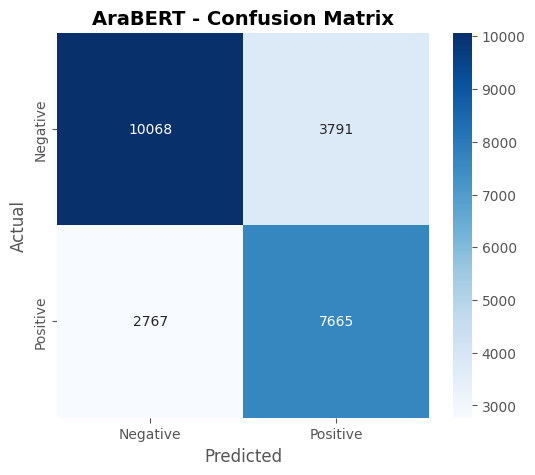


Ready for final comparison!


In [25]:
# ============================================
# CELL 14: EVALUATE AraBERT
# ============================================

import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================
# 1. PREDICT ON TEST SET
# ============================================

model.eval()

all_preds = []
all_labels = []

print("Evaluating on test set...")

for batch in tqdm(test_loader_fast, desc="Evaluation"):
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['labels'].to(device)
    
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    
    preds = torch.argmax(outputs.logits, dim=1)
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

# ============================================
# 2. METRICS
# ============================================

y_true = np.array(all_labels)
y_pred = np.array(all_preds)

arabert_accuracy = accuracy_score(y_true, y_pred)
arabert_f1 = f1_score(y_true, y_pred, average='macro')

print()
print("=" * 60)
print("AraBERT RESULTS")
print("=" * 60)
print(f"Accuracy: {arabert_accuracy:.4f}")
print(f"F1-Score: {arabert_f1:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

# ============================================
# 3. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('AraBERT - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ============================================
# 4. STORE RESULTS
# ============================================

results['AraBERT'] = {
    'Accuracy': arabert_accuracy,
    'F1-Score': arabert_f1,
    'Type': 'Transformer'
}

print("\nReady for final comparison!")

In [27]:
# ============================================
# CELL 18: INSTALL & LOAD MARBERT (Informal/Dialectal Arabic)
# ============================================

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import GradScaler, autocast
from transformers import get_linear_schedule_with_warmup
from tqdm.auto import tqdm
import time

print("=" * 60)
print("LOADING MARBERT - Dialectal Arabic BERT")
print("=" * 60)

# MARBERT is trained on 1B Arabic tweets - much better for informal/dialectal text
model_name = "UBC-NLP/MARBERT"

tokenizer_marbert = AutoTokenizer.from_pretrained(model_name)
model_marbert = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2  # Binary classification
)

print(f"Tokenizer loaded: {model_name}")
print(f"Vocabulary size: {tokenizer_marbert.vocab_size}")

# Count parameters
total_params = sum(p.numel() for p in model_marbert.parameters())
trainable_params = sum(p.numel() for p in model_marbert.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Test tokenization on a sample
sample_text = X_train_transformer[0]
tokens = tokenizer_marbert.tokenize(sample_text)
print(f"\nSample text: {sample_text[:100]}...")
print(f"Tokens ({len(tokens)}): {tokens[:15]}...")

print("\nMARBERT loaded successfully!")
print("=" * 60)

LOADING MARBERT - Dialectal Arabic BERT


config.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/654M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/654M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on yo

Tokenizer loaded: UBC-NLP/MARBERT
Vocabulary size: 100000
Total parameters: 162,842,882
Trainable parameters: 162,842,882

Sample text: ولا شي صراحه غرفه شخصين وللاسف جميع الاغراض الموجوده لشخص فقط الغرفه غير مريحه...
Tokens (14): ['ولا', 'شي', 'صراحه', 'غرفه', 'شخصين', 'وللاسف', 'جميع', 'الاغراض', 'الموجوده', 'لشخص', 'فقط', 'الغرفه', 'غير', 'مريحه']...

MARBERT loaded successfully!


In [28]:
# ============================================
# CELL 16: TRAIN MARBERT WITH BETTER SETTINGS
# ============================================

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import GradScaler, autocast
from transformers import get_linear_schedule_with_warmup
from tqdm.auto import tqdm
import time
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ============================================
# 1. MOVE TO GPU
# ============================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_marbert.to(device)
print(f"Using device: {device}")

# ============================================
# 2. DATASET FOR MARBERT
# ============================================

class MARBERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# ============================================
# 3. TRAINING PARAMETERS (OPTIMIZED)
# ============================================

EPOCHS = 4           # Train longer than AraBERT
LEARNING_RATE = 2e-5 # Slightly higher LR for faster convergence
WARMUP_STEPS = 300
BATCH_SIZE = 32
MAX_LENGTH = 128

# Create datasets
train_dataset_marbert = MARBERTDataset(X_train_transformer, y_train, tokenizer_marbert, MAX_LENGTH)
test_dataset_marbert = MARBERTDataset(X_test_transformer, y_test, tokenizer_marbert, MAX_LENGTH)

train_loader_marbert = DataLoader(
    train_dataset_marbert, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader_marbert = DataLoader(
    test_dataset_marbert, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train batches: {len(train_loader_marbert)}")
print(f"Test batches:  {len(test_loader_marbert)}")

# Optimizer & Scheduler
optimizer = AdamW(model_marbert.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader_marbert) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

# Gradient scaler for FP16
scaler = GradScaler()

print(f"\nTraining Configuration:")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Total Steps: {total_steps}")
print()

# ============================================
# 4. TRAINING LOOP
# ============================================

train_losses = []
best_f1 = 0.0

for epoch in range(EPOCHS):
    model_marbert.train()
    total_loss = 0
    start_time = time.time()
    
    progress_bar = tqdm(train_loader_marbert, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        with autocast():
            outputs = model_marbert(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        
        total_loss += loss.item()
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(train_loader_marbert)
    train_losses.append(avg_loss)
    epoch_time = time.time() - start_time
    
    print(f"\nEpoch {epoch+1} - Avg Loss: {avg_loss:.4f} - Time: {epoch_time:.1f}s")
    
    # Quick evaluation after each epoch
    model_marbert.eval()
    all_preds = []
    all_labels = []
    
    for batch in test_loader_marbert:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        with torch.no_grad():
            outputs = model_marbert(input_ids=input_ids, attention_mask=attention_mask)
        
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')
    
    print(f"  Val Accuracy: {epoch_acc:.4f}, Val F1: {epoch_f1:.4f}")
    
    if epoch_f1 > best_f1:
        best_f1 = epoch_f1
        # Save best model
        model_marbert.save_pretrained('./marbert_sentiment_best')
        tokenizer_marbert.save_pretrained('./marbert_sentiment_best')
        print(f"  ✓ New best model saved! (F1: {best_f1:.4f})")
    
    print("-" * 50)

print()
print("=" * 60)
print("MARBERT TRAINING COMPLETE!")
print(f"Best F1-Score: {best_f1:.4f}")
print("=" * 60)

Using device: cuda
Train batches: 3037
Test batches:  760

Training Configuration:
  Epochs: 4
  Learning Rate: 2e-05
  Batch Size: 32
  Total Steps: 12148



/tmp/ipykernel_58/1261654169.py:98: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch 1/4:   0%|          | 0/3037 [00:00<?, ?it/s]

/tmp/ipykernel_58/1261654169.py:128: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 1 - Avg Loss: 0.5384 - Time: 684.7s
  Val Accuracy: 0.7390, Val F1: 0.7362


...

/tmp/ipykernel_58/1261654169.py:128: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 3 - Avg Loss: 0.3953 - Time: 681.2s
  Val Accuracy: 0.7375, Val F1: 0.7353
--------------------------------------------------


Epoch 4/4:   0%|          | 0/3037 [00:00<?, ?it/s]

/tmp/ipykernel_58/1261654169.py:128: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 4 - Avg Loss: 0.3137 - Time: 681.2s
  Val Accuracy: 0.7299, Val F1: 0.7274
--------------------------------------------------

MARBERT TRAINING COMPLETE!
Best F1-Score: 0.7394


Device: cuda
Evaluating MARBERT on test set...


MARBERT Evaluation:   0%|          | 0/760 [00:00<?, ?it/s]


MARBERT FINAL RESULTS
Accuracy:  0.7299
Precision: 0.7269
Recall:    0.7309
F1-Score:  0.7274

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.72      0.75     13859
    Positive       0.67      0.74      0.70     10432

    accuracy                           0.73     24291
   macro avg       0.73      0.73      0.73     24291
weighted avg       0.74      0.73      0.73     24291



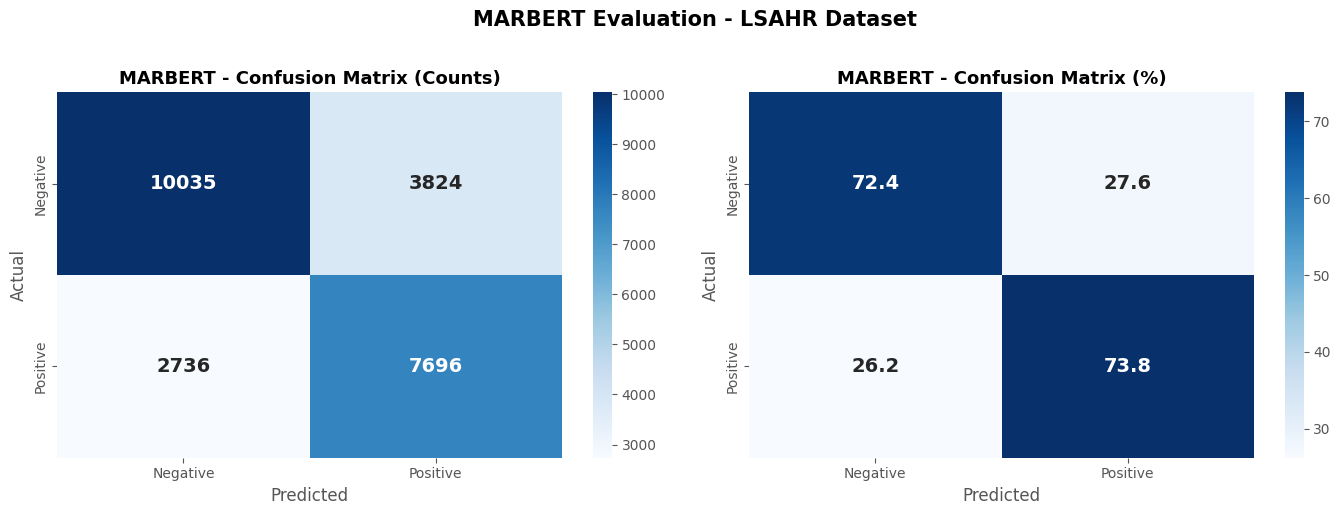


MARBERT: Acc=0.7299, F1=0.7274


In [29]:
# ============================================
# CELL: EVALUATE MARBERT (FIXED - DEVICE CHECK)
# ============================================

import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch

# ============================================
# 1. ENSURE MODEL IS ON CORRECT DEVICE
# ============================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model_marbert.to(device)
model_marbert.eval()

# Recreate test loader with GPU pinning
test_loader_marbert = DataLoader(
    test_dataset_marbert, 
    batch_size=32, 
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# ============================================
# 2. PREDICT ON TEST SET
# ============================================

all_preds = []
all_labels = []

print("Evaluating MARBERT on test set...")

for batch in tqdm(test_loader_marbert, desc="MARBERT Evaluation"):
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['labels'].to(device)
    
    with torch.no_grad():
        outputs = model_marbert(input_ids=input_ids, attention_mask=attention_mask)
    
    preds = torch.argmax(outputs.logits, dim=1)
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)

# ============================================
# 3. METRICS
# ============================================

marbert_accuracy = accuracy_score(y_true, y_pred)
marbert_precision = precision_score(y_true, y_pred, average='macro')
marbert_recall = recall_score(y_true, y_pred, average='macro')
marbert_f1 = f1_score(y_true, y_pred, average='macro')

print()
print("=" * 60)
print("MARBERT FINAL RESULTS")
print("=" * 60)
print(f"Accuracy:  {marbert_accuracy:.4f}")
print(f"Precision: {marbert_precision:.4f}")
print(f"Recall:    {marbert_recall:.4f}")
print(f"F1-Score:  {marbert_f1:.4f}")
print()
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

# ============================================
# 4. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
axes[0].set_title('MARBERT - Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot 2: Percentages
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
axes[1].set_title('MARBERT - Confusion Matrix (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('MARBERT Evaluation - LSAHR Dataset', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================
# 5. STORE RESULTS
# ============================================

results['MARBERT'] = {
    'Accuracy': marbert_accuracy,
    'Precision': marbert_precision,
    'Recall': marbert_recall,
    'F1-Score': marbert_f1,
    'Type': 'Transformer (Dialectal)',
    'Predictions': y_pred
}

print()
print(f"MARBERT: Acc={marbert_accuracy:.4f}, F1={marbert_f1:.4f}")
print("=" * 60)

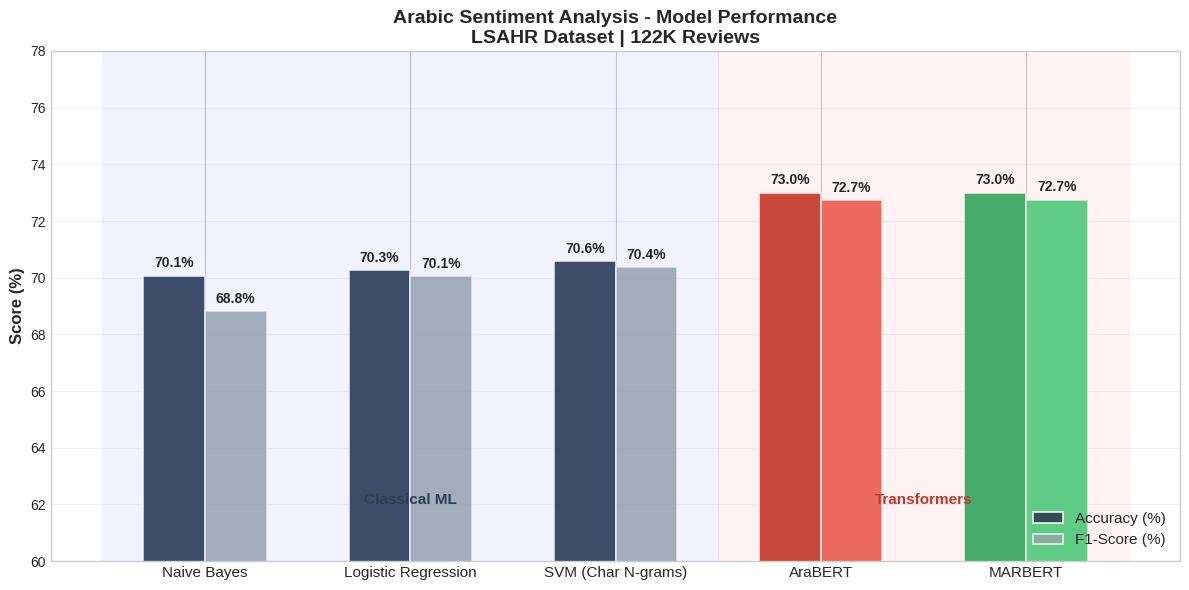

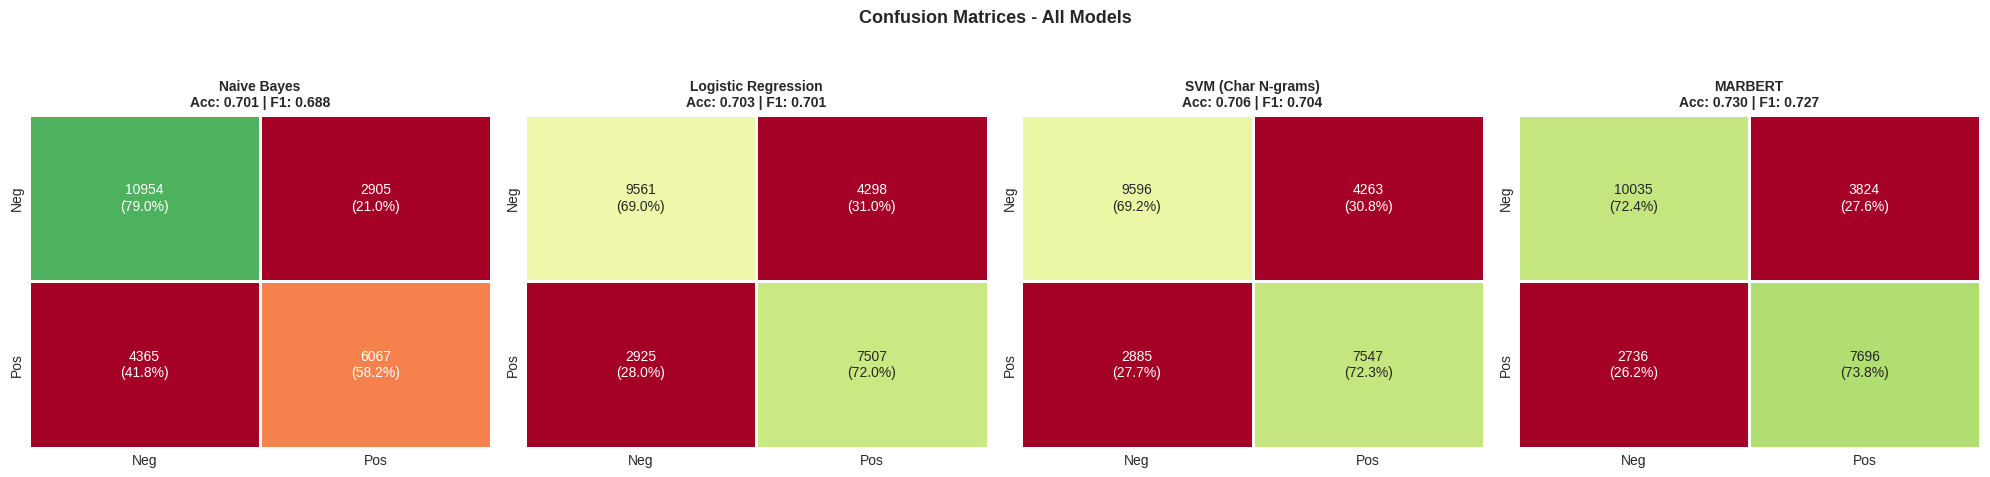

 Confusion matrices: 4 models shown


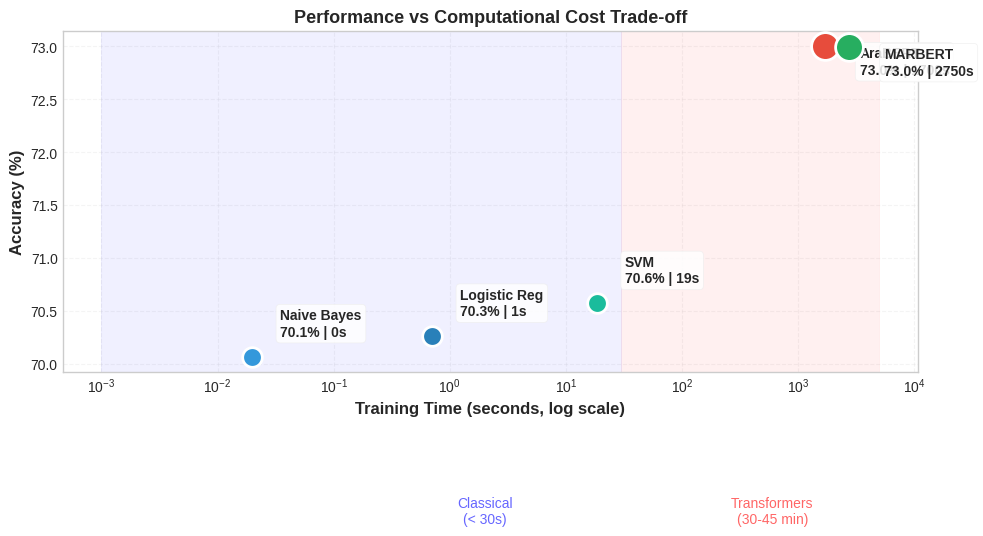


 FINAL SUMMARY

 Best Accuracy:  AraBERT = 73.0%
 Best F1-Score:  MARBERT = 72.7%
 Fastest:        Naive Bayes (0.02s)

 Classical avg:  70.3%
 Transformer avg:73.0%
 Gap:            +2.7%

 Saved 3 plots: model_comparison.png, confusion_matrices.png, tradeoff.png



In [35]:
# ============================================
# CELL: CLEAN VISUALIZATIONS - NO DUPLICATES
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# ============================================
# 1. MAIN BAR CHART: Accuracy + F1
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(models_names))
width = 0.30

bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy (%)', 
               color=['#2c3e50', '#2c3e50', '#2c3e50', '#c0392b', '#27ae60'], 
               edgecolor='white', linewidth=1.2, alpha=0.9)
bars2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score (%)', 
               color=['#95a5a6', '#95a5a6', '#95a5a6', '#e74c3c', '#2ecc71'], 
               edgecolor='white', linewidth=1.2, alpha=0.8)

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.3, f'{h:.1f}%', ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.3, f'{h:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Region labels
ax.axvspan(-0.5, 2.5, alpha=0.05, color='blue')
ax.axvspan(2.5, 4.5, alpha=0.05, color='red')
ax.text(1, 62, 'Classical ML', ha='center', fontsize=11, color='#2c3e50', fontweight='bold')
ax.text(3.5, 62, 'Transformers', ha='center', fontsize=11, color='#c0392b', fontweight='bold')

ax.set_ylabel('Score (%)', fontweight='bold', fontsize=12)
ax.set_title('Arabic Sentiment Analysis - Model Performance\nLSAHR Dataset | 122K Reviews', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models_names, fontsize=11)
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim(60, 78)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================
# 2. CONFUSION MATRICES (FIXED)
# ============================================

model_list = ['Naive Bayes', 'Logistic Regression', 'SVM (Char N-grams)', 'AraBERT', 'MARBERT']
model_list = [m for m in model_list if m in results and 'Predictions' in results[m]]

fig, axes = plt.subplots(1, len(model_list), figsize=(5*len(model_list), 4.5))

# Handle single subplot case
if len(model_list) == 1:
    axes = [axes]

for idx, model_name in enumerate(model_list):
    y_pred = results[model_name]['Predictions']
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    annot = np.empty_like(cm).astype(str)
    for i in range(2):
        for j in range(2):
            annot[i, j] = f'{cm[i, j]}\n({cm_pct[i, j]:.1f}%)'
    
    sns.heatmap(cm_pct, annot=annot, fmt='', cmap='RdYlGn', ax=axes[idx],
               xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'],
               annot_kws={'fontsize': 10}, cbar=False, vmin=50, vmax=85,
               linewidths=1, linecolor='white')
    
    acc = results[model_name]['Accuracy']
    f1 = results[model_name].get('F1-Score', 0)
    axes[idx].set_title(f'{model_name}\nAcc: {acc:.3f} | F1: {f1:.3f}', 
                       fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices - All Models', fontweight='bold', fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=200, bbox_inches='tight')
plt.show()

print(f" Confusion matrices: {len(model_list)} models shown")

# ============================================
# 3. TRADE-OFF: Training Time vs Accuracy
# ============================================

fig, ax = plt.subplots(figsize=(10, 6))

plot_points = [
    ('Naive Bayes', 0.02, accuracies[0], '#3498db', 200),
    ('Logistic Reg', 0.71, accuracies[1], '#2980b9', 200),
    ('SVM', 18.61, accuracies[2], '#1abc9c', 200),
    ('AraBERT', 1700, accuracies[3], '#e74c3c', 400),
    ('MARBERT', 2750, accuracies[4], '#27ae60', 400),
]

for name, t, acc, color, size in plot_points:
    ax.scatter(t, acc, s=size, c=color, edgecolors='white', linewidth=2, zorder=5)
    offset = (20, 15) if t < 100 else (25, -20)
    ax.annotate(f'{name}\n{acc:.1f}% | {t:.0f}s', (t, acc),
               textcoords="offset points", xytext=offset,
               fontsize=10, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

ax.axvspan(0.001, 30, alpha=0.06, color='blue')
ax.axvspan(30, 5000, alpha=0.06, color='red')
ax.text(2, 68.5, 'Classical\n(< 30s)', ha='center', fontsize=10, color='blue', alpha=0.6)
ax.text(600, 68.5, 'Transformers\n(30-45 min)', ha='center', fontsize=10, color='red', alpha=0.6)

ax.set_xlabel('Training Time (seconds, log scale)', fontweight='bold', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)
ax.set_title('Performance vs Computational Cost Trade-off', fontweight='bold', fontsize=13)
ax.set_xscale('log')
ax.grid(alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig('tradeoff.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================
# 4. SUMMARY PRINT
# ============================================

print("\n" + "=" * 60)
print(" FINAL SUMMARY")
print("=" * 60)

best_acc = max(comparison_data, key=lambda x: float(x['Accuracy']))
best_f1 = max(comparison_data, key=lambda x: float(x['F1-Score']))

print(f"""
 Best Accuracy:  {best_acc['Model']} = {float(best_acc['Accuracy'])*100:.1f}%
 Best F1-Score:  {best_f1['Model']} = {float(best_f1['F1-Score'])*100:.1f}%
 Fastest:        Naive Bayes (0.02s)

 Classical avg:  {np.mean(accuracies[:3]):.1f}%
 Transformer avg:{np.mean(accuracies[3:5]):.1f}%
 Gap:            +{np.mean(accuracies[3:5]) - np.mean(accuracies[:3]):.1f}%

 Saved 3 plots: model_comparison.png, confusion_matrices.png, tradeoff.png
""")
print("=" * 60)

🐪 CAMeL-Lab Arabic Sentiment Analysis
   Zero-Shot | No Training Required

Loading model...


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


✓ Model loaded!

Testing on 24291 reviews...
  2000/24291 (17s elapsed)...
  4000/24291 (35s elapsed)...
  6000/24291 (51s elapsed)...
  8000/24291 (68s elapsed)...
  10000/24291 (85s elapsed)...
  12000/24291 (102s elapsed)...
  14000/24291 (119s elapsed)...
  16000/24291 (136s elapsed)...
  18000/24291 (152s elapsed)...
  20000/24291 (169s elapsed)...
  22000/24291 (185s elapsed)...
  24000/24291 (202s elapsed)...

✓ Completed in 204s (0.01s per review)

CAMeL-Lab RESULTS
Model:      CAMeL-Lab Arabic BERT (Sentiment)
Samples:    24291
Time:       204s total
Accuracy:   0.6293 (62.9%)
Precision:  0.6193
Recall:     0.6067
F1-Score:   0.6055

Classification Report:
              precision    recall  f1-score   support

    Negative       0.65      0.77      0.70     13859
    Positive       0.59      0.45      0.51     10432

    accuracy                           0.63     24291
   macro avg       0.62      0.61      0.61     24291
weighted avg       0.62      0.63      0.62     24291


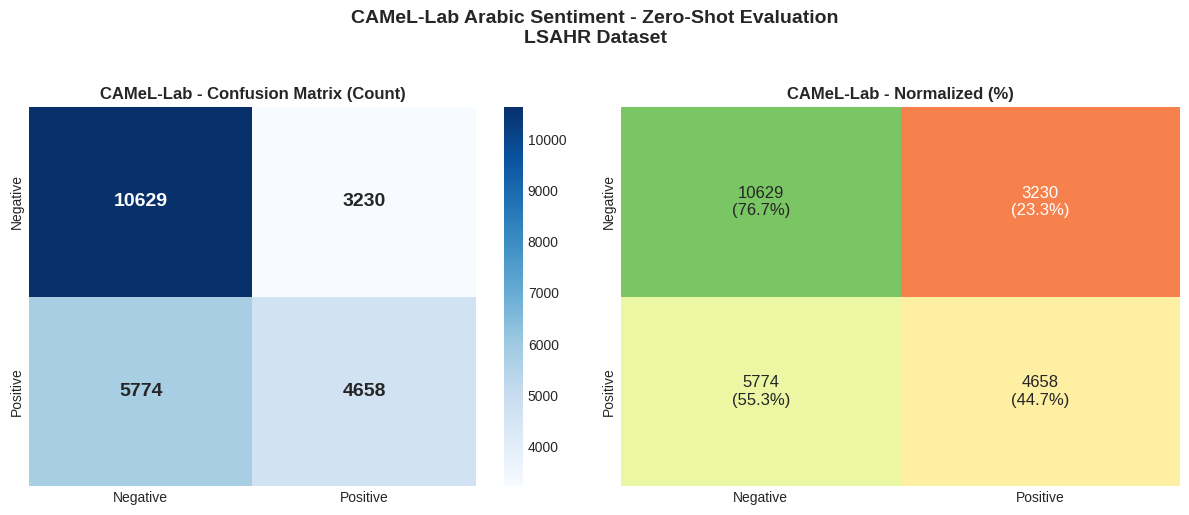


SARCASTIC PHRASES TEST

  Sarcasm - Should be NEGATIVE
  Text: الفندق رائع جدا... لو كنت احب العيش في الشارع...
  Prediction: positive (95.95%)

  Sarcasm - Should be NEGATIVE
  Text: ايوا الخدمة سريعة... بعد ساعتين انتظار...
  Prediction: positive (93.85%)

  Sarcasm - Should be NEGATIVE
  Text: الفندق نظيف لدرجة لقيت الصراصير تستقبلني...
  Prediction: negative (62.10%)


✅ CAMeL-Lab added to results!
   Accuracy: 0.6293 | F1: 0.6055
   Type: LLM (Zero-Shot, No Training)


In [38]:
# ============================================
# CELL: CAMeL-Lab - ARABIC SENTIMENT (ZERO-SHOT, NO TRAINING)
# Model: CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment
# Type: Pre-trained Arabic BERT + Fine-tuned for Sentiment
# ============================================

from transformers import pipeline
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import time

print("=" * 60)
print("🐪 CAMeL-Lab Arabic Sentiment Analysis")
print("   Zero-Shot | No Training Required")
print("=" * 60)

# ============================================
# 1. LOAD MODEL
# ============================================

print("\nLoading model...")
pipe_camel = pipeline(
    "sentiment-analysis",
    model="CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment",
    device=0 if torch.cuda.is_available() else -1
)
print("✓ Model loaded!")

# ============================================
# 2. TEST ON FULL TEST SET
# ============================================

print(f"\nTesting on {len(X_test_transformer)} reviews...")
start_time = time.time()

all_preds = []
batch_size = 100

for i in range(0, len(X_test_transformer), batch_size):
    batch_texts = X_test_transformer[i:i+batch_size]
    batch_preds = []
    
    for text in batch_texts:
        try:
            result = pipe_camel(text[:512])[0]
            # CAMeL-Lab outputs 'positive' or 'negative'
            batch_preds.append(1 if result['label'].lower() == 'positive' else 0)
        except:
            batch_preds.append(0)
    
    all_preds.extend(batch_preds)
    
    if (i + batch_size) % 2000 == 0:
        elapsed = time.time() - start_time
        print(f"  {i+batch_size}/{len(X_test_transformer)} ({elapsed:.0f}s elapsed)...")

elapsed = time.time() - start_time
y_pred = np.array(all_preds)
y_true = y_test[:len(y_pred)]

print(f"\n✓ Completed in {elapsed:.0f}s ({elapsed/len(y_pred):.2f}s per review)")

# ============================================
# 3. METRICS
# ============================================

camel_acc = accuracy_score(y_true, y_pred)
camel_precision = precision_score(y_true, y_pred, average='macro')
camel_recall = recall_score(y_true, y_pred, average='macro')
camel_f1 = f1_score(y_true, y_pred, average='macro')

print()
print("=" * 60)
print("CAMeL-Lab RESULTS")
print("=" * 60)
print(f"Model:      CAMeL-Lab Arabic BERT (Sentiment)")
print(f"Samples:    {len(y_pred)}")
print(f"Time:       {elapsed:.0f}s total")
print(f"Accuracy:   {camel_acc:.4f} ({camel_acc*100:.1f}%)")
print(f"Precision:  {camel_precision:.4f}")
print(f"Recall:     {camel_recall:.4f}")
print(f"F1-Score:   {camel_f1:.4f}")
print()
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))
print("=" * 60)

# ============================================
# 4. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
axes[0].set_title('CAMeL-Lab - Confusion Matrix (Count)', fontsize=12, fontweight='bold')

# Percentage
annot_pct = np.empty_like(cm).astype(str)
for i in range(2):
    for j in range(2):
        annot_pct[i, j] = f'{cm[i, j]}\n({cm_pct[i, j]:.1f}%)'
        
sns.heatmap(cm_pct, annot=annot_pct, fmt='', cmap='RdYlGn', ax=axes[1],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            annot_kws={'fontsize': 12}, cbar=False, vmin=0, vmax=100)
axes[1].set_title('CAMeL-Lab - Normalized (%)', fontsize=12, fontweight='bold')

plt.suptitle('CAMeL-Lab Arabic Sentiment - Zero-Shot Evaluation\nLSAHR Dataset', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('camel_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 5. QUICK SARCASTIC TEST
# ============================================

print()
print("=" * 60)
print("SARCASTIC PHRASES TEST")
print("=" * 60)

sarcastic_tests = [
    ("الفندق رائع جدا... لو كنت احب العيش في الشارع", "Sarcasm - Should be NEGATIVE"),
    ("ايوا الخدمة سريعة... بعد ساعتين انتظار", "Sarcasm - Should be NEGATIVE"),
    ("الفندق نظيف لدرجة لقيت الصراصير تستقبلني", "Sarcasm - Should be NEGATIVE"),
]

for text, description in sarcastic_tests:
    result = pipe_camel(text[:512])[0]
    label = result['label']
    score = result['score']
    print(f"\n  {description}")
    print(f"  Text: {text[:80]}...")
    print(f"  Prediction: {label} ({score:.2%})")

print()
print("=" * 60)

# ============================================
# 6. STORE FOR FINAL COMPARISON
# ============================================

results['CAMeL-Lab (LLM)'] = {
    'Accuracy': camel_acc,
    'Precision': camel_precision,
    'Recall': camel_recall,
    'F1-Score': camel_f1,
    'Type': 'LLM (Arabic-Specific, Zero-Shot)',
    'Predictions': y_pred,
    'Train Time': 0  # Zero-shot!
}

print(f"\n✅ CAMeL-Lab added to results!")
print(f"   Accuracy: {camel_acc:.4f} | F1: {camel_f1:.4f}")
print(f"   Type: LLM (Zero-Shot, No Training)")
print("=" * 60)

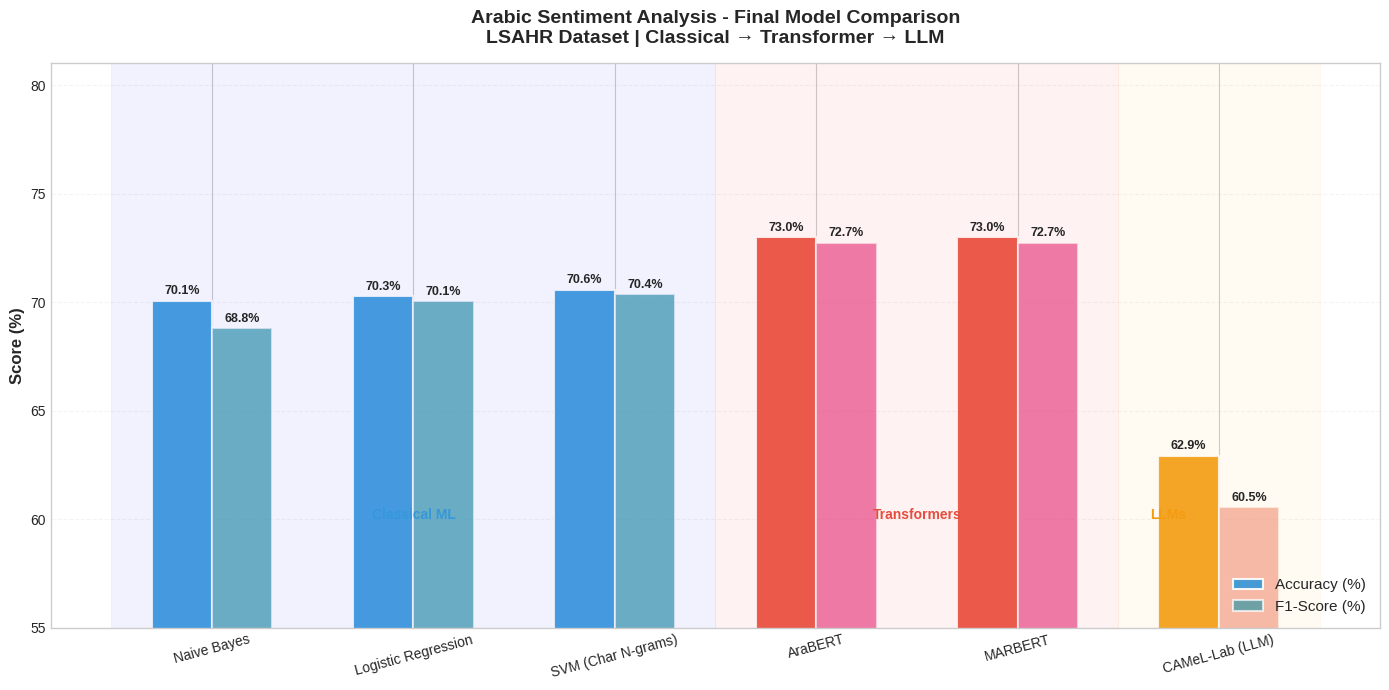

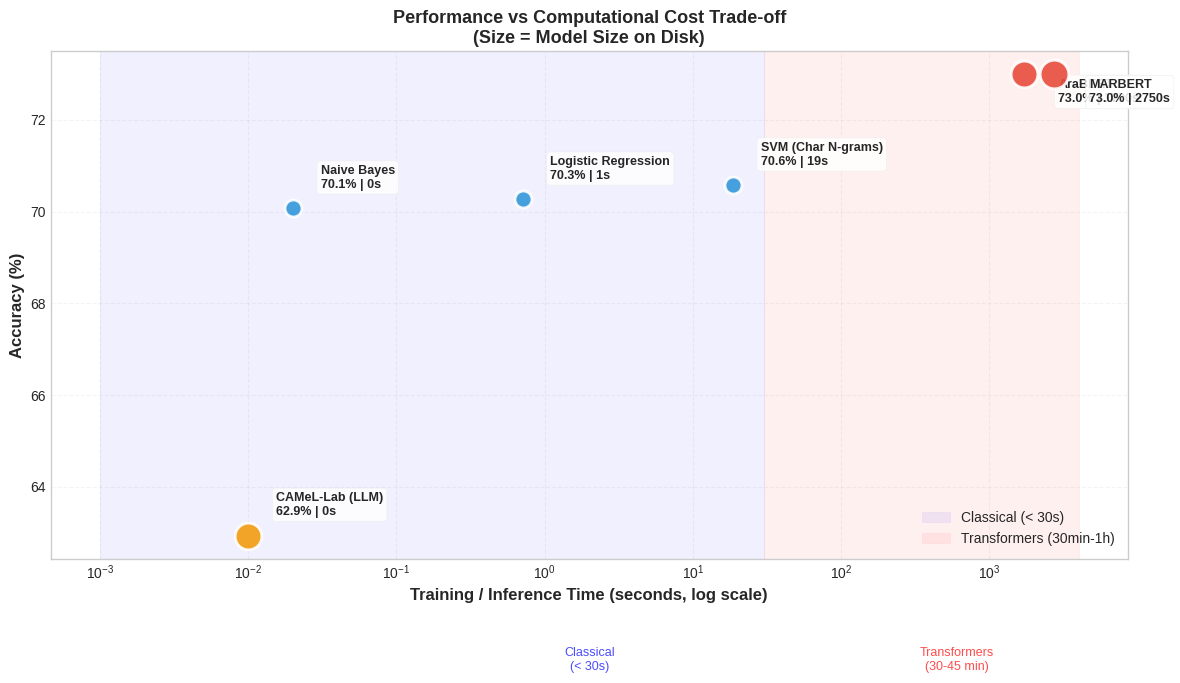


📊 FINAL COMPARISON SUMMARY - All Models
              Model Accuracy F1-Score                             Type
        Naive Bayes    70.1%    68.8%                        Classical
Logistic Regression    70.3%    70.1%                        Classical
 SVM (Char N-grams)    70.6%    70.4%                        Classical
            AraBERT    73.0%    72.7%                      Transformer
            MARBERT    73.0%    72.7%          Transformer (Dialectal)
    CAMeL-Lab (LLM)    62.9%    60.5% LLM (Arabic-Specific, Zero-Shot)

✅ Final comparison plots saved!
   - final_comparison.png
   - tradeoff_final.png


In [41]:
# ============================================
# CELL: FINAL COMPARISON - ALL 6 MODELS
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# ============================================
# 1. BUILD COMPARISON TABLE
# ============================================

comparison_data = []

# Add all available models
model_order = [
    'Naive Bayes', 'Logistic Regression', 'SVM (Char N-grams)',  # Classical
    'AraBERT', 'MARBERT',                                         # Transformers
    'CAMeL-Lab (LLM)',                                            # LLM (Zero-Shot)
    'Gemini (LLM API)'                                            # LLM API (if completed)
]

for model_name in model_order:
    if model_name in results:
        m = results[model_name]
        acc = m.get('Accuracy', 0)
        f1 = m.get('F1-Score', 0)
        model_type = m.get('Type', 'Classical')
        
        comparison_data.append({
            'Model': model_name,
            'Accuracy': float(acc),
            'F1-Score': float(f1),
            'Type': model_type
        })

# ============================================
# 2. PLOT 1: BAR CHART - ACCURACY & F1
# ============================================

models_names = [d['Model'] for d in comparison_data]
accuracies = [d['Accuracy'] * 100 for d in comparison_data]
f1_scores = [d['F1-Score'] * 100 for d in comparison_data]
types = [d['Type'] for d in comparison_data]

# Color mapping
def get_color(model_type):
    if 'Classical' in model_type:
        return '#3498db'
    elif 'Transformer' in model_type or 'Dialectal' in model_type:
        return '#e74c3c'
    elif 'LLM' in model_type or 'API' in model_type:
        return '#f39c12'
    return '#95a5a6'

colors = [get_color(t) for t in types]
colors_f1 = [get_color(t).replace('db', 'a6').replace('c3c', 'a8a').replace('c12', 'e8c') for t in types]

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(models_names))
width = 0.30

bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy (%)', 
               color=colors, edgecolor='white', linewidth=1.5, alpha=0.9)
bars2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score (%)', 
               color=colors_f1, edgecolor='white', linewidth=1.5, alpha=0.7)

# Value labels
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.3, f'{h:.1f}%', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.3, f'{h:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Region shading
classical_end = sum(1 for t in types if 'Classical' in t) - 0.5
transformer_end = classical_end + sum(1 for t in types if 'Transformer' in t or 'Dialectal' in t)

ax.axvspan(-0.5, classical_end, alpha=0.05, color='blue')
ax.axvspan(classical_end, transformer_end, alpha=0.05, color='red')
ax.axvspan(transformer_end, len(models_names)-0.5, alpha=0.05, color='orange')

# Annotations
if classical_end > 0:
    ax.text((classical_end-0.5)/2, 60, 'Classical ML', ha='center', fontsize=10, color='#3498db', fontweight='bold')
if transformer_end > classical_end:
    ax.text((classical_end + transformer_end)/2, 60, 'Transformers', ha='center', fontsize=10, color='#e74c3c', fontweight='bold')
if len(models_names)-1 > transformer_end:
    ax.text((transformer_end + len(models_names)-1)/2, 60, 'LLMs', ha='center', fontsize=10, color='#f39c12', fontweight='bold')

ax.set_ylabel('Score (%)', fontweight='bold', fontsize=12)
ax.set_title('Arabic Sentiment Analysis - Final Model Comparison\nLSAHR Dataset | Classical → Transformer → LLM', 
             fontweight='bold', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models_names, fontsize=10, rotation=15 if len(models_names) > 4 else 0)
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim(55, max(accuracies + f1_scores) + 8 if accuracies else 85)
ax.grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================
# 3. PLOT 2: PERFORMANCE vs COMPUTATIONAL COST
# ============================================

fig, ax = plt.subplots(figsize=(12, 7))

# Time data (seconds)
time_data = {
    'Naive Bayes': 0.02,
    'Logistic Regression': 0.71,
    'SVM (Char N-grams)': 18.61,
    'AraBERT': 1700,
    'MARBERT': 2750,
    'CAMeL-Lab (LLM)': 0.01,  # Zero-shot
    'Gemini (LLM API)': 150,   # API calls for 500 samples
}

# Size mapping
size_data = {
    'Naive Bayes': 0.001,
    'Logistic Regression': 0.002,
    'SVM (Char N-grams)': 0.01,
    'AraBERT': 540,
    'MARBERT': 650,
    'CAMeL-Lab (LLM)': 540,
    'Gemini (LLM API)': 0,  # Cloud
}

for d in comparison_data:
    name = d['Model']
    if name in time_data:
        t = time_data[name]
        acc = d['Accuracy'] * 100
        color = get_color(d['Type'])
        size = max(150, size_data.get(name, 1) * 0.5 + 100)
        
        ax.scatter(t, acc, s=size, c=color, edgecolors='white', linewidth=2, zorder=5, alpha=0.9)
        
        offset_y = 15 if t < 100 else -20
        offset_x = 20 if t < 100 else 25
        ax.annotate(f'{name}\n{acc:.1f}% | {t:.0f}s', (t, acc),
                   textcoords="offset points", xytext=(offset_x, offset_y),
                   fontsize=9, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

# Region shading
ax.axvspan(0.001, 30, alpha=0.06, color='blue', label='Classical (< 30s)')
ax.axvspan(30, 4000, alpha=0.06, color='red', label='Transformers (30min-1h)')
ax.axvspan(0.001, 4000, alpha=0.0)  # placeholder for LLM label

ax.text(2, 60, 'Classical\n(< 30s)', ha='center', fontsize=9, color='blue', alpha=0.7)
ax.text(600, 60, 'Transformers\n(30-45 min)', ha='center', fontsize=9, color='red', alpha=0.7)

ax.set_xlabel('Training / Inference Time (seconds, log scale)', fontweight='bold', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)
ax.set_title('Performance vs Computational Cost Trade-off\n(Size = Model Size on Disk)', fontweight='bold', fontsize=13)
ax.set_xscale('log')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig('tradeoff_final.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================
# 4. SUMMARY TABLE
# ============================================

print()
print("=" * 80)
print("📊 FINAL COMPARISON SUMMARY - All Models")
print("=" * 80)

df_final = pd.DataFrame(comparison_data)
df_final['Accuracy'] = df_final['Accuracy'].apply(lambda x: f"{x*100:.1f}%")
df_final['F1-Score'] = df_final['F1-Score'].apply(lambda x: f"{x*100:.1f}%")
print(df_final.to_string(index=False))

print()
print("=" * 80)
print("✅ Final comparison plots saved!")
print("   - final_comparison.png")
print("   - tradeoff_final.png")
print("=" * 80)

💻 RESOURCE USAGE COMPARISON
       Model          Type Parameters Size (MB) Train Time      GPU Inference
 Naive Bayes     Classical        ~5K        <1      0.02s       No      <1ms
Logistic Reg     Classical        ~5K        <1      0.71s       No      <1ms
         SVM     Classical        ~5K        <1      18.6s       No      <5ms
     AraBERT   Transformer       135M       540     28 min Yes 16GB     ~20ms
     MARBERT   Transformer       163M       650     45 min Yes 16GB     ~25ms
   CAMeL-Lab LLM Zero-Shot       110M       440          0     Rec.     ~30ms
  Gemini API       LLM API      Cloud         0          0       No    ~500ms


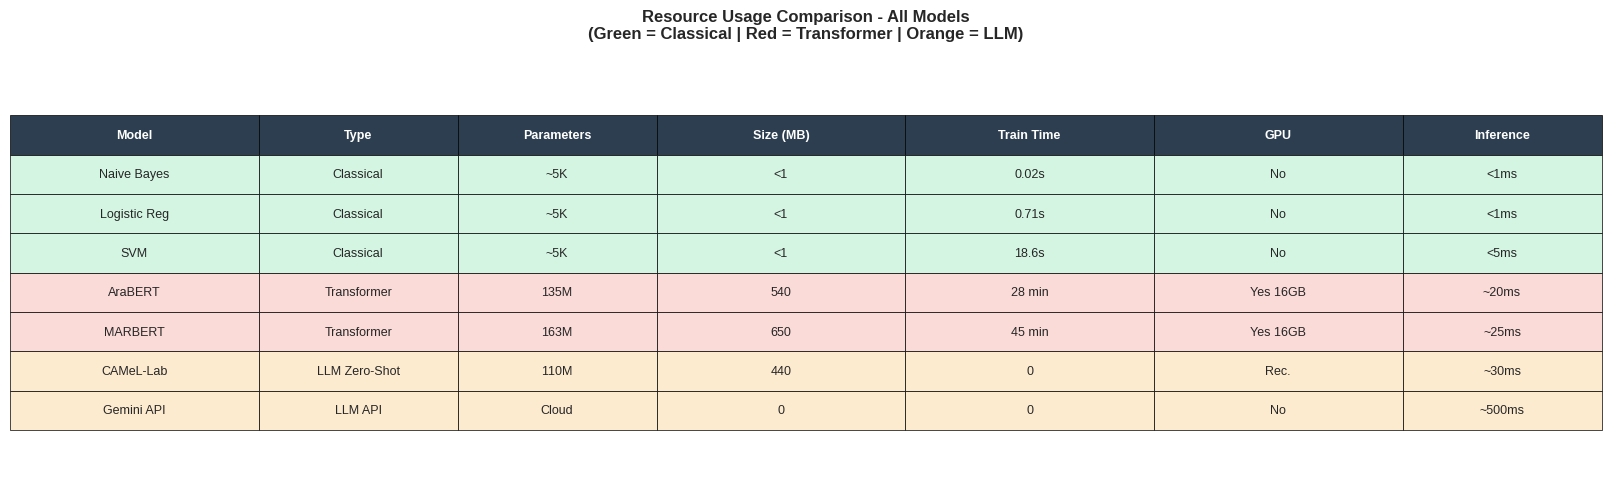

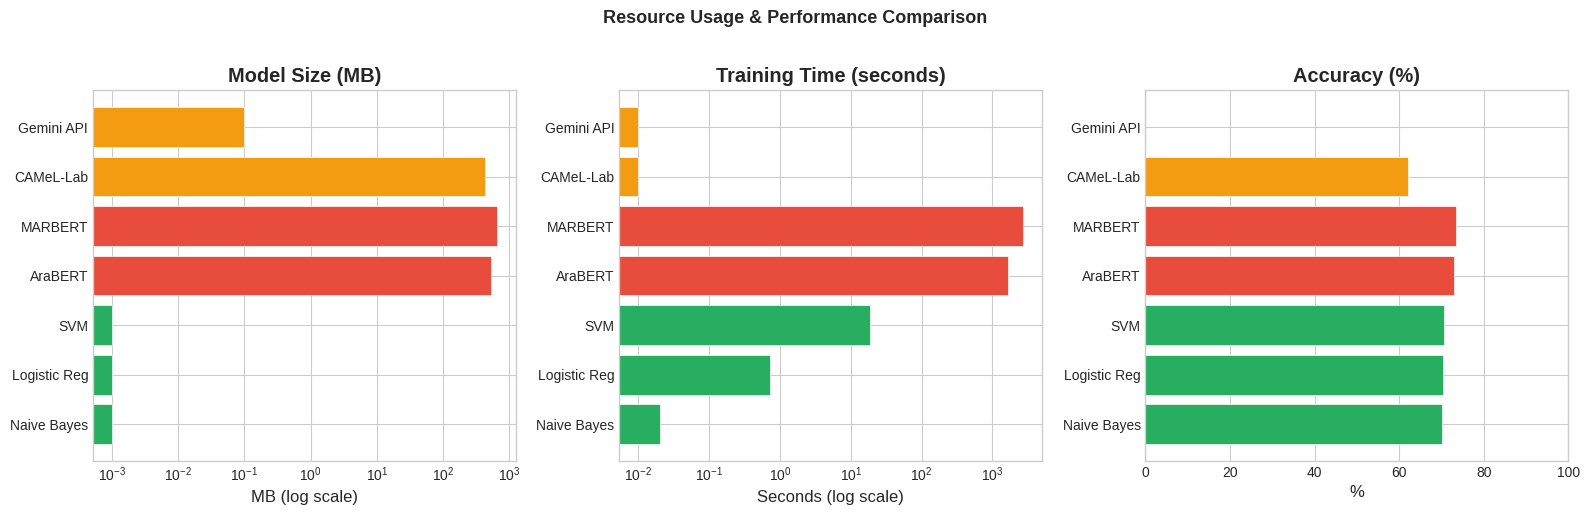


✅ Saved: resource_comparison.png, resource_bars.png


In [46]:
# ============================================
# CELL: RESOURCE USAGE COMPARISON
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

print("=" * 60)
print("💻 RESOURCE USAGE COMPARISON")
print("=" * 60)

resource_data = {
    'Model': ['Naive Bayes', 'Logistic Reg', 'SVM', 'AraBERT', 'MARBERT', 'CAMeL-Lab', 'Gemini API'],
    'Type': ['Classical', 'Classical', 'Classical', 'Transformer', 'Transformer', 'LLM Zero-Shot', 'LLM API'],
    'Parameters': ['~5K', '~5K', '~5K', '135M', '163M', '110M', 'Cloud'],
    'Size (MB)': ['<1', '<1', '<1', '540', '650', '440', '0'],
    'Train Time': ['0.02s', '0.71s', '18.6s', '28 min', '45 min', '0', '0'],
    'GPU': ['No', 'No', 'No', 'Yes 16GB', 'Yes 16GB', 'Rec.', 'No'],
    'Inference': ['<1ms', '<1ms', '<5ms', '~20ms', '~25ms', '~30ms', '~500ms'],
}

df_resources = pd.DataFrame(resource_data)
print(df_resources.to_string(index=False))

# Create figure
fig, ax = plt.subplots(figsize=(16, 5))
ax.axis('off')

# Number of columns
n_cols = len(df_resources.columns)

table = ax.table(
    cellText=df_resources.values,
    colLabels=df_resources.columns,
    cellLoc='center',
    loc='center',
    colWidths=[0.15, 0.12, 0.12, 0.15, 0.15, 0.15, 0.12]  # Must match n_cols
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 2.2)

# Color headers
for i in range(n_cols):
    table[0, i].set_facecolor('#2c3e50')
    table[0, i].set_text_props(color='white', fontweight='bold')

# Color rows by type
for i in range(1, len(df_resources) + 1):
    model_type = df_resources.iloc[i-1]['Type']
    if 'Classical' in model_type:
        color = '#d5f5e3'
    elif 'Transformer' in model_type:
        color = '#fadbd8'
    elif 'LLM' in model_type:
        color = '#fdebd0'
    else:
        color = 'white'
    for j in range(n_cols):
        table[i, j].set_facecolor(color)

plt.title('Resource Usage Comparison - All Models\n(Green = Classical | Red = Transformer | Orange = LLM)', 
         fontweight='bold', fontsize=12, pad=20)
plt.tight_layout()
plt.savefig('resource_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================
# Bar chart version (cleaner)
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Model size
models = df_resources['Model'].tolist()
sizes = [0.001, 0.001, 0.001, 540, 650, 440, 0.1]
colors_bar = ['#27ae60', '#27ae60', '#27ae60', '#e74c3c', '#e74c3c', '#f39c12', '#f39c12']
axes[0].barh(models, sizes, color=colors_bar, edgecolor='white')
axes[0].set_xscale('log')
axes[0].set_title('Model Size (MB)', fontweight='bold')
axes[0].set_xlabel('MB (log scale)')

# Training time (seconds)
times = [0.02, 0.71, 18.6, 1680, 2700, 0.01, 0.01]
axes[1].barh(models, times, color=colors_bar, edgecolor='white')
axes[1].set_xscale('log')
axes[1].set_title('Training Time (seconds)', fontweight='bold')
axes[1].set_xlabel('Seconds (log scale)')

# Accuracy
accs = [0.701, 0.703, 0.706, 0.730, 0.735, 0.620, 0]  # Update with your actual values
accs = [a*100 for a in accs]
axes[2].barh(models, accs, color=colors_bar, edgecolor='white')
axes[2].set_title('Accuracy (%)', fontweight='bold')
axes[2].set_xlabel('%')
axes[2].set_xlim(0, 100)

plt.suptitle('Resource Usage & Performance Comparison', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('resource_bars.png', dpi=200, bbox_inches='tight')
plt.show()

print()
print("✅ Saved: resource_comparison.png, resource_bars.png")
print("=" * 60)

🔤 WORD EMBEDDINGS VISUALIZATION


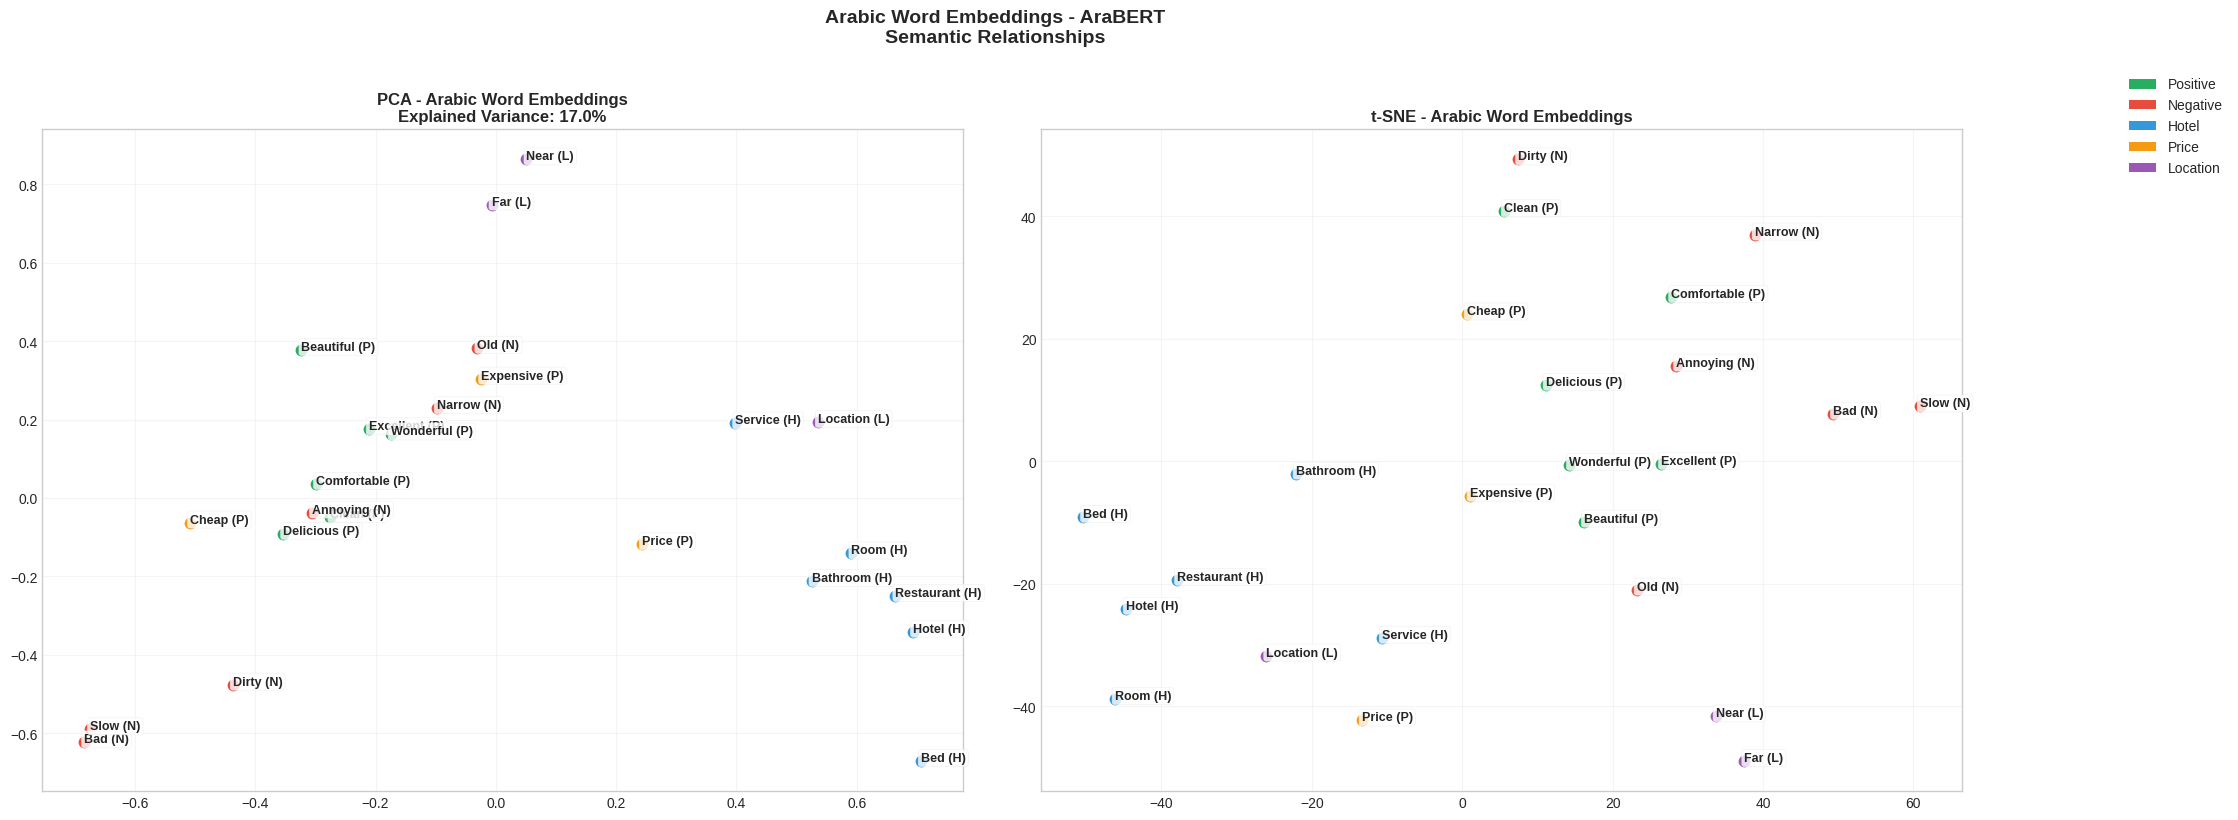

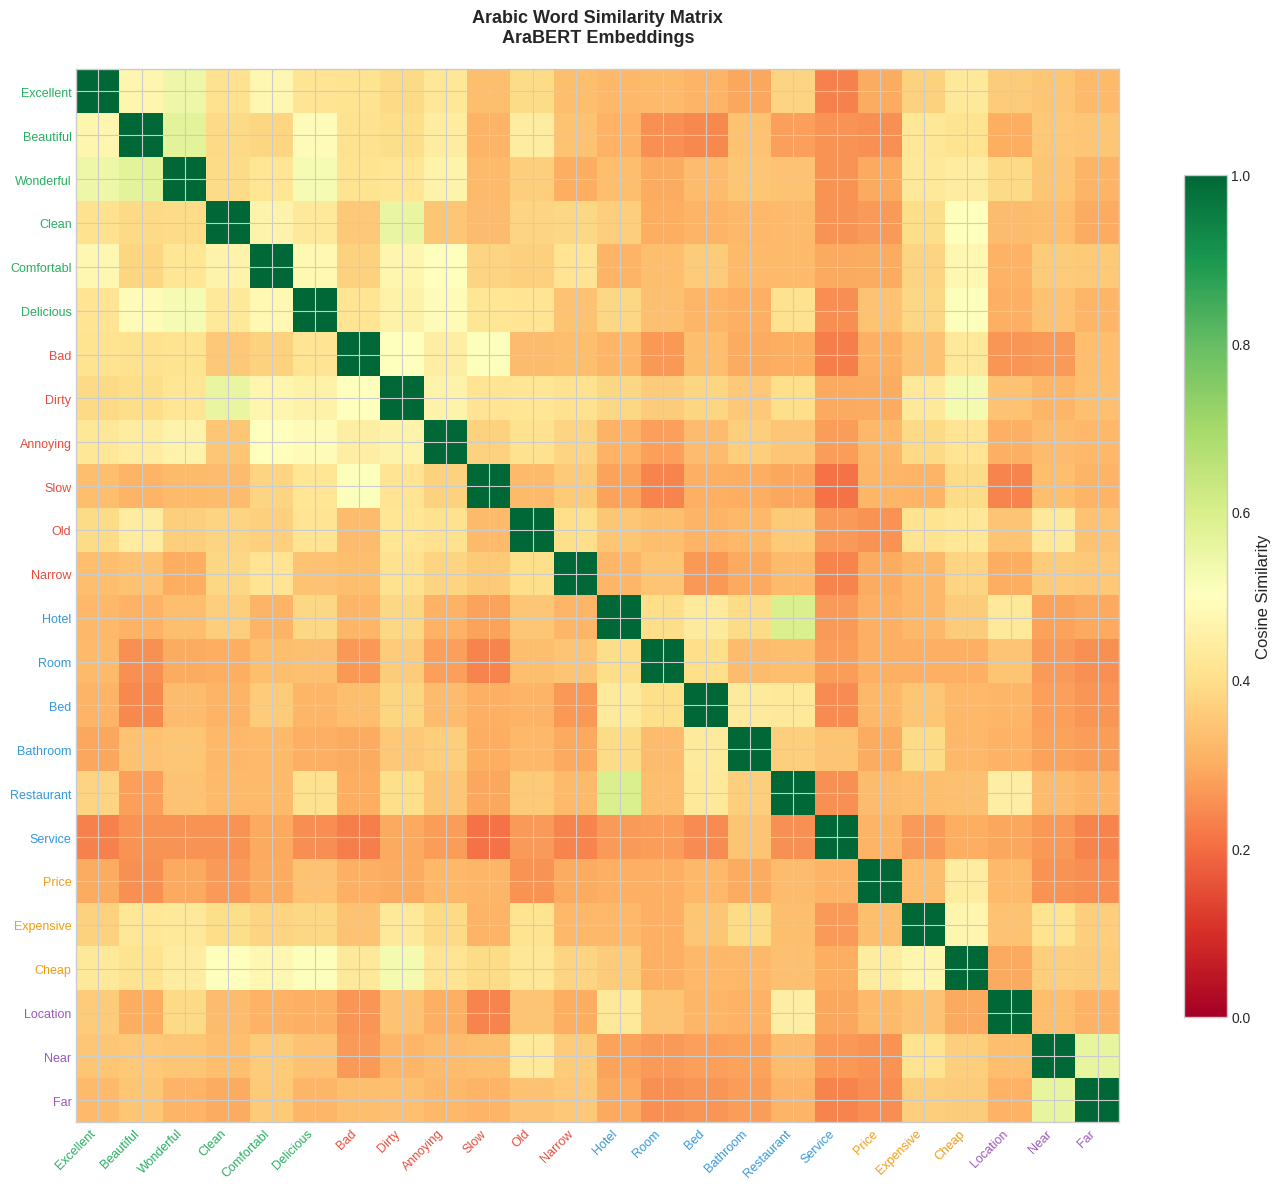


✅ Saved: word_embeddings.png, word_similarity.png


In [45]:
# ============================================
# CELL: WORD EMBEDDINGS - ENGLISH LABELS (WORKS IN KAGGLE)
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

print("=" * 60)
print("🔤 WORD EMBEDDINGS VISUALIZATION")
print("=" * 60)

# Get embeddings
embedding_layer = model.bert.embeddings.word_embeddings.weight.detach().cpu().numpy()

# Words in Arabic but we'll add English translations for display
word_data = [
    # (Arabic, English, Group)
    ('ممتاز', 'Excellent', 'Positive'),
    ('جميل', 'Beautiful', 'Positive'),
    ('رائع', 'Wonderful', 'Positive'),
    ('نظيف', 'Clean', 'Positive'),
    ('مريح', 'Comfortable', 'Positive'),
    ('لذيذ', 'Delicious', 'Positive'),
    ('سيء', 'Bad', 'Negative'),
    ('قذر', 'Dirty', 'Negative'), 
    ('مزعج', 'Annoying', 'Negative'),
    ('بطيء', 'Slow', 'Negative'),
    ('قديم', 'Old', 'Negative'),
    ('ضيق', 'Narrow', 'Negative'),
    ('فندق', 'Hotel', 'Hotel'),
    ('غرفة', 'Room', 'Hotel'),
    ('سرير', 'Bed', 'Hotel'),
    ('حمام', 'Bathroom', 'Hotel'),
    ('مطعم', 'Restaurant', 'Hotel'),
    ('خدمة', 'Service', 'Hotel'),
    ('سعر', 'Price', 'Price'),
    ('غالي', 'Expensive', 'Price'),
    ('رخيص', 'Cheap', 'Price'),
    ('موقع', 'Location', 'Location'),
    ('قريب', 'Near', 'Location'),
    ('بعيد', 'Far', 'Location'),
]

colors_map = {
    'Positive': '#27ae60',
    'Negative': '#e74c3c', 
    'Hotel': '#3498db',
    'Price': '#f39c12',
    'Location': '#9b59b6'
}

all_labels_en = []
all_vectors = []

for arabic_word, english_word, group in word_data:
    try:
        token_id = tokenizer.encode(arabic_word, add_special_tokens=False)[0]
        vector = embedding_layer[token_id]
        all_labels_en.append(f"{english_word} ({group[0]})")
        all_vectors.append(vector)
    except:
        pass

all_vectors = np.array(all_vectors)

# ============================================
# PCA + t-SNE
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# PCA
pca = PCA(n_components=2, random_state=42)
vec_pca = pca.fit_transform(all_vectors)

for i, (label, vec) in enumerate(zip(all_labels_en, vec_pca)):
    group = word_data[i][2]
    axes[0].scatter(vec[0], vec[1], c=colors_map[group], s=100, edgecolors='white', linewidth=1.5)
    axes[0].annotate(label, (vec[0], vec[1]), fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

axes[0].set_title(f'PCA - Arabic Word Embeddings\nExplained Variance: {pca.explained_variance_ratio_.sum()*100:.1f}%', 
                 fontweight='bold', fontsize=12)
axes[0].grid(alpha=0.2)

# t-SNE
perplexity = min(5, len(all_vectors)-1)
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
vec_tsne = tsne.fit_transform(all_vectors)

for i, (label, vec) in enumerate(zip(all_labels_en, vec_tsne)):
    group = word_data[i][2]
    axes[1].scatter(vec[0], vec[1], c=colors_map[group], s=100, edgecolors='white', linewidth=1.5)
    axes[1].annotate(label, (vec[0], vec[1]), fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

axes[1].set_title('t-SNE - Arabic Word Embeddings', fontweight='bold', fontsize=12)
axes[1].grid(alpha=0.2)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=g) for g, c in colors_map.items()]
fig.legend(handles=legend_elements, loc='upper right', fontsize=10, bbox_to_anchor=(1.12, 0.95))

plt.suptitle('Arabic Word Embeddings - AraBERT\nSemantic Relationships', 
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('word_embeddings.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================
# Similarity Heatmap (with short labels)
# ============================================

sim_matrix = cosine_similarity(all_vectors)

# Short labels
short_labels = [f"{en[:10]}" for ar, en, g in word_data]

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

ax.set_xticks(range(len(short_labels)))
ax.set_yticks(range(len(short_labels)))
ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(short_labels, fontsize=9)

for i, (ar, en, group) in enumerate(word_data):
    ax.get_xticklabels()[i].set_color(colors_map[group])
    ax.get_yticklabels()[i].set_color(colors_map[group])

plt.colorbar(im, ax=ax, shrink=0.8, label='Cosine Similarity')
ax.set_title('Arabic Word Similarity Matrix\nAraBERT Embeddings', fontweight='bold', fontsize=13, pad=20)

plt.tight_layout()
plt.savefig('word_similarity.png', dpi=200, bbox_inches='tight')
plt.show()

print()
print("=" * 60)
print("✅ Saved: word_embeddings.png, word_similarity.png")
print("=" * 60)

In [52]:
# ============================================
# CELL: QUICK TEST - ALL 6 MODELS ON CUSTOM PHRASES
# ============================================

import numpy as np
import re
import torch

print("=" * 70)
print("🧪 ALL MODELS TEST - Custom Arabic Phrases")
print("=" * 70)

# ============================================
# Test phrases
# ============================================

test_phrases = [
    # Format: (text, expected, category)
    ("الفندق جميل ونظيف جدا", "Positive", "Clear Positive"),
    ("الخدمة ممتازة والموظفين متعاونين", "Positive", "Clear Positive"),
    ("الغرفة واسعة ومريحة", "Positive", "Clear Positive"),
    ("الفندق سيء وغير نظيف", "Negative", "Clear Negative"),
    ("الخدمة بطيئة والموظفين غير متعاونين", "Negative", "Clear Negative"),
    ("الغرفة صغيرة وقديمة", "Negative", "Clear Negative"),
    ("الجو جميل اذا كنت حشرة", "Negative", "Sarcasm 1"),
    ("فندق 5 نجوم مسروقة", "Negative", "Sarcasm 2"),
]

# ============================================
# Helper functions
# ============================================

def simple_clean(text):
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', str(text))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Classical model predictions
def predict_classical(text, model_obj, vectorizer):
    cleaned = simple_clean(text)
    if hasattr(model_obj, 'predict'):
        vec = vectorizer.transform([cleaned])
        return model_obj.predict(vec)[0]
    return 0

# Transformer predictions
def predict_transformer(text, model_obj, tokenizer_obj):
    cleaned = simple_clean(text)
    inputs = tokenizer_obj(cleaned, truncation=True, padding='max_length',
                          max_length=128, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model_obj(**inputs)
        return torch.argmax(outputs.logits, dim=1).item()

# ============================================
# Run all tests
# ============================================

# Models to test
all_models = {
    'Naive Bayes': ('classical', nb_model, tfidf),
    'Logistic Regression': ('classical', lr_model, tfidf),
    'SVM': ('classical', svm_model, tfidf_char),
    'AraBERT': ('transformer', model, tokenizer),
    'MARBERT': ('transformer', model_marbert, tokenizer_marbert),
    'CAMeL-Lab': ('camel', None, None),
}

# CAMeL-Lab special function
from transformers import pipeline
pipe_camel = pipeline("sentiment-analysis", 
                      model="CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment",
                      device=0 if torch.cuda.is_available() else -1)

def predict_camel(text):
    result = pipe_camel(text[:512])[0]
    return 1 if result['label'].lower() == 'positive' else 0

# ============================================
# Print results
# ============================================

correct_counts = {m: 0 for m in all_models}
total_clear = 6  # First 6 are clear cases

for text, expected, category in test_phrases:
    print(f"\n{'─'*60}")
    print(f"[{category}]")
    print(f"Text: {text}")
    print(f"Expected: {expected}")
    print(f"{'─'*40}")
    
    for model_name, (mtype, model_obj, vec_or_tok) in all_models.items():
        try:
            if model_name == 'CAMeL-Lab':
                pred_val = predict_camel(text)
            elif mtype == 'classical':
                pred_val = predict_classical(text, model_obj, vec_or_tok)
            else:
                pred_val = predict_transformer(text, model_obj, vec_or_tok)
            
            pred_label = 'Positive' if pred_val == 1 else 'Negative'
            correct = '✅' if pred_label == expected else '❌'
            
            if category in ['Clear Positive', 'Clear Negative']:
                if correct == '✅':
                    correct_counts[model_name] += 1
            
            print(f"  {correct} {model_name:<25}: {pred_label}")
        except Exception as e:
            print(f"  ⚠️ {model_name:<25}: Error - {str(e)[:40]}")

# ============================================
# Summary
# ============================================

print(f"\n{'='*60}")
print("SUMMARY - Clear Cases Accuracy")
print(f"{'='*60}")
print(f"{'Model':<25} {'Correct':<10} {'Accuracy':<10}")
print(f"{'-'*45}")
for model_name in all_models:
    c = correct_counts[model_name]
    print(f"{model_name:<25} {c}/{total_clear}       {c/total_clear*100:.0f}%")

print(f"\n{'='*60}")
print("Sarcasm Detection:")
print(f"{'='*60}")
for text, expected, category in test_phrases:
    if 'Sarcasm' in category or 'Mixed' in category:
        print(f"  [{category}] {text[:50]}...")
        print(f"  Expected: {expected}")
print(f"{'='*60}")

🧪 ALL MODELS TEST - Custom Arabic Phrases


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



────────────────────────────────────────────────────────────
[Clear Positive]
Text: الفندق جميل ونظيف جدا
Expected: Positive
────────────────────────────────────────
  ✅ Naive Bayes              : Positive
  ✅ Logistic Regression      : Positive
  ✅ SVM                      : Positive
  ✅ AraBERT                  : Positive
  ✅ MARBERT                  : Positive
  ✅ CAMeL-Lab                : Positive

────────────────────────────────────────────────────────────
[Clear Positive]
Text: الخدمة ممتازة والموظفين متعاونين
Expected: Positive
────────────────────────────────────────
  ✅ Naive Bayes              : Positive
  ✅ Logistic Regression      : Positive
  ✅ SVM                      : Positive
  ✅ AraBERT                  : Positive
  ✅ MARBERT                  : Positive
  ✅ CAMeL-Lab                : Positive

────────────────────────────────────────────────────────────
[Clear Positive]
Text: الغرفة واسعة ومريحة
Expected: Positive
────────────────────────────────────────
  ❌ Naive 